In [1]:
%load_ext autoreload
%autoreload 2

from seek_code import SEEK
from backbone import Backbone
from retrieval import Retrieval
from projector import Projector
from data_handler import EleHandler
from concept_head_tunneled import ConceptHeadTunneled, categorical_CE_loss, CrossedHeadNN, MultiHeadNN

from pathlib import Path
from torch.utils.data import DataLoader, Subset

/data/vision/beery/scratch/antoine/micromamba/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
dataset = EleHandler(subset='IDI_6')
train_indices, test_indices = dataset.split_perpendicular_to_elephants_and_encounters(split_sizes=[0.5,0.5], hour_delta = 0.2)

train_subset = Subset(dataset, train_indices)
test_subset = Subset(dataset, test_indices)

train_loader = DataLoader(train_subset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_subset, batch_size=64, shuffle=True)

### Baseline 1 - MegaDescriptor out of the box, with savannah elephants pretraining

In [ ]:
code = '[prep_100epochs]STEP_1_MegaDescriptor_savannah_elephants'

MD_savannah = Backbone(model_name="MegaDescriptor", pretraining="savannah_elephants", experiment_code=code)
r = Retrieval(experiment_code = code)
r.evaluate_model(model = MD_savannah, train_loader=train_loader, test_loader=test_loader)


/data/vision/beery/scratch/antoine/CBM_reid/methods/backbone.py:33: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load(weight_path, map_location=self.devi

evaluating backbone
Train Recalls:
Recall@1: 6.71%
Recall@5: 12.52%
Recall@10: 15.90%
Recall@20: 21.20%
Recall@100: 45.18%
Test Recalls:
Recall@1: 23.15%
Recall@5: 32.98%
Recall@10: 38.08%
Recall@20: 45.16%
Recall@100: 67.71%


{1: 0.23153084539223154,
 5: 0.32977913175932977,
 10: 0.38080731150038083,
 20: 0.45163747143945165,
 100: 0.6770753998476771}

23.15% with IDI_6 and savannah_elephants weights

## Baseline 2_1 - MD finetuned 

Finetuned using the whole complete dataset

In [ ]:
code = '[prep_100epochs]STEP_2_MegaDescriptor_finetuned_on_all_data'

dataset = EleHandler(subset='IDI')

#print(len(dataset))
train_indices, test_indices = dataset.split_perpendicular_to_elephants_and_encounters(split_sizes=[0.5,0.5], hour_delta = 0.2)

train_subset = Subset(dataset, train_indices)
test_subset = Subset(dataset, test_indices)

train_loader = DataLoader(train_subset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_subset, batch_size=64, shuffle=True)

MD_finetuned_on_all = Backbone(model_name="MegaDescriptor", pretraining="savannah_elephants", experiment_code=code, lr=5e-6)
MD_finetuned_on_all.train(train_loader, test_loader, num_epochs=10)
MD_finetuned_on_all.test(train_loader, test_loader)

38.38% with IDI_6 and MD_finetuned weights

## Baseline 2_2 : finetuning MegaDescriptor

We have used finetuned weights earlier but I believe that these weights have been obtained before restricting to the IDI_6 subset. Thus, to obtain a fair baseline, I will finetune it again on the same data. 

In [3]:
code = '[prep_100epochs]STEP_3_MegaDescriptor_finetunining_on_IDI6'

MD_finetuned_IDI6 = Backbone(model_name="MegaDescriptor", pretraining="savannah_elephants", experiment_code=code, lr=5e-6)
MD_finetuned_IDI6.train(train_loader, test_loader, num_epochs=2)
MD_finetuned_IDI6.test(train_loader, test_loader)

/data/vision/beery/scratch/antoine/CBM_reid/methods/backbone.py:34: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load(weight_path, map_location=self.devi

Backbone parameters require gradients: True
embeddings torch.Size([64, 2304]) labels torch.Size([64])
embeddings torch.Size([64, 2304]) labels torch.Size([64])
embeddings torch.Size([64, 2304]) labels torch.Size([64])
embeddings torch.Size([64, 2304]) labels torch.Size([64])
embeddings torch.Size([64, 2304]) labels torch.Size([64])
embeddings torch.Size([64, 2304]) labels torch.Size([64])
embeddings torch.Size([64, 2304]) labels torch.Size([64])
embeddings torch.Size([64, 2304]) labels torch.Size([64])
embeddings torch.Size([64, 2304]) labels torch.Size([64])
embeddings torch.Size([64, 2304]) labels torch.Size([64])
embeddings torch.Size([64, 2304]) labels torch.Size([64])
embeddings torch.Size([64, 2304]) labels torch.Size([64])
embeddings torch.Size([64, 2304]) labels torch.Size([64])
embeddings torch.Size([64, 2304]) labels torch.Size([64])
embeddings torch.Size([64, 2304]) labels torch.Size([64])
embeddings torch.Size([64, 2304]) labels torch.Size([64])
embeddings torch.Size([64, 2

KeyboardInterrupt: 

I used the wrong backbon in the test but the result is about **31.0%**.

### Baseline 2_3 (Sanity check): Hopefully, the new architecture allows a very similar training if we choose alpha = 0

In [ ]:
code = '[debug-3-epochs]STEP_4_Sanity_check'

MD_for_concepts = Backbone(model_name="MegaDescriptor", pretraining="backbone_for_concepts_w", experiment_code=code)
MD_finedtuned = Backbone(model_name="MegaDescriptor", pretraining="savannah_elephants", experiment_code=code)
pr = Projector(loss_type ='ArcFace', lr=5e-6, scale=64, margin=0.5, experiment_code=code, intervention_fn=None, alpha = 0)
concept_head = ConceptHeadTunneled(loss=categorical_CE_loss, experiment_code = code, layer = CrossedHeadNN(), reset_weights=False)

# Freeze other models and unfreeze the projector
MD_for_concepts.freeze()
MD_finedtuned.unfreeze()
concept_head.freeze()
pr.unfreeze()

# Train the model
pr.train(
    train_loader, 
    test_loader, 
    backbone_for_concepts=MD_for_concepts, 
    backbone=MD_finedtuned, 
    concept_head=concept_head, 
    num_epochs=3)

test_intervention_fns = {
    "0% Correction": None,
    "0% Correction Hard": SEEK.hard
}

# Run the structured test method
pr.test(
    backbone_for_concepts=MD_for_concepts, 
    backbone=MD_finedtuned, 
    concept_head=concept_head, 
    train_loader=train_loader, 
    test_loader=test_loader, 
    intervention_fns=test_intervention_fns
)


NameError: name 'Backbone' is not defined

## Baseline 3 : CBM (under correction or not ?)

To-do :
- Direct CBM ?
- A projector with alpha = 1 and corrected concepts will give a maximum attainable reID
- Train a CBM with uncorrected concepts, show uncorrected concepts have a bad ReID capibility :
    - lowers expectation toward CHAIR without any correction 
    - justifies the need for a embedding pipeline too

In [1]:
from seek_code import SEEK
from backbone import Backbone
from retrieval import Retrieval
from projector import Projector
from data_handler import EleHandler
from concept_head_tunneled import ConceptHeadTunneled, categorical_CE_loss, CrossedHeadNN, MultiHeadNN

from pathlib import Path
from torch.utils.data import DataLoader, Subset

/data/vision/beery/scratch/antoine/micromamba/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
dataset = EleHandler(subset='IDI_6')
train_indices, test_indices = dataset.split_perpendicular_to_elephants_and_encounters(split_sizes=[0.5,0.5], hour_delta = 0.2)

train_subset = Subset(dataset, train_indices)
test_subset = Subset(dataset, test_indices)

train_loader = DataLoader(train_subset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_subset, batch_size=64, shuffle=True)

In [ ]:
code = '[debug5epochs]CBM'

MD_for_concepts = Backbone(model_name="MegaDescriptor", pretraining="backbone_for_concepts_w", experiment_code=code)
concept_head = ConceptHeadTunneled(loss=categorical_CE_loss, experiment_code = code, layer = CrossedHeadNN(), reset_weights=False)

# Freeze other models and unfreeze the projector
MD_for_concepts.freeze()
concept_head.freeze()

test_intervention_fns = {
    "0% Correction": None,
    "0% Correction Hard": SEEK.hard,
    "100% correction": SEEK.perfect_correction,
    "Oracle correction": SEEK.oracle_correction
}

# Run the structured test method
concept_head.retrieval_test(
    backbone_for_concepts=MD_for_concepts, 
    train_loader=train_loader, 
    test_loader=test_loader, 
    intervention_fns=test_intervention_fns
)


NameError: name 'Backbone' is not defined

/data/vision/beery/scratch/antoine/CBM_reid/methods/backbone.py:34: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load(weight_path, map_location=self.devi

Model loaded from /data/vision/beery/scratch/antoine/CBM_reid/weights/concept_w.pt
loading weights for the concept head

Testing with cosine_sim distance:
Retrieval with 0% Correction correction-------------------------------------


/data/vision/beery/scratch/antoine/CBM_reid/methods/retrieval.py:320: UserWarning: The palette list has more values (14) than needed (13), which may not be intended.
  sns.scatterplot(


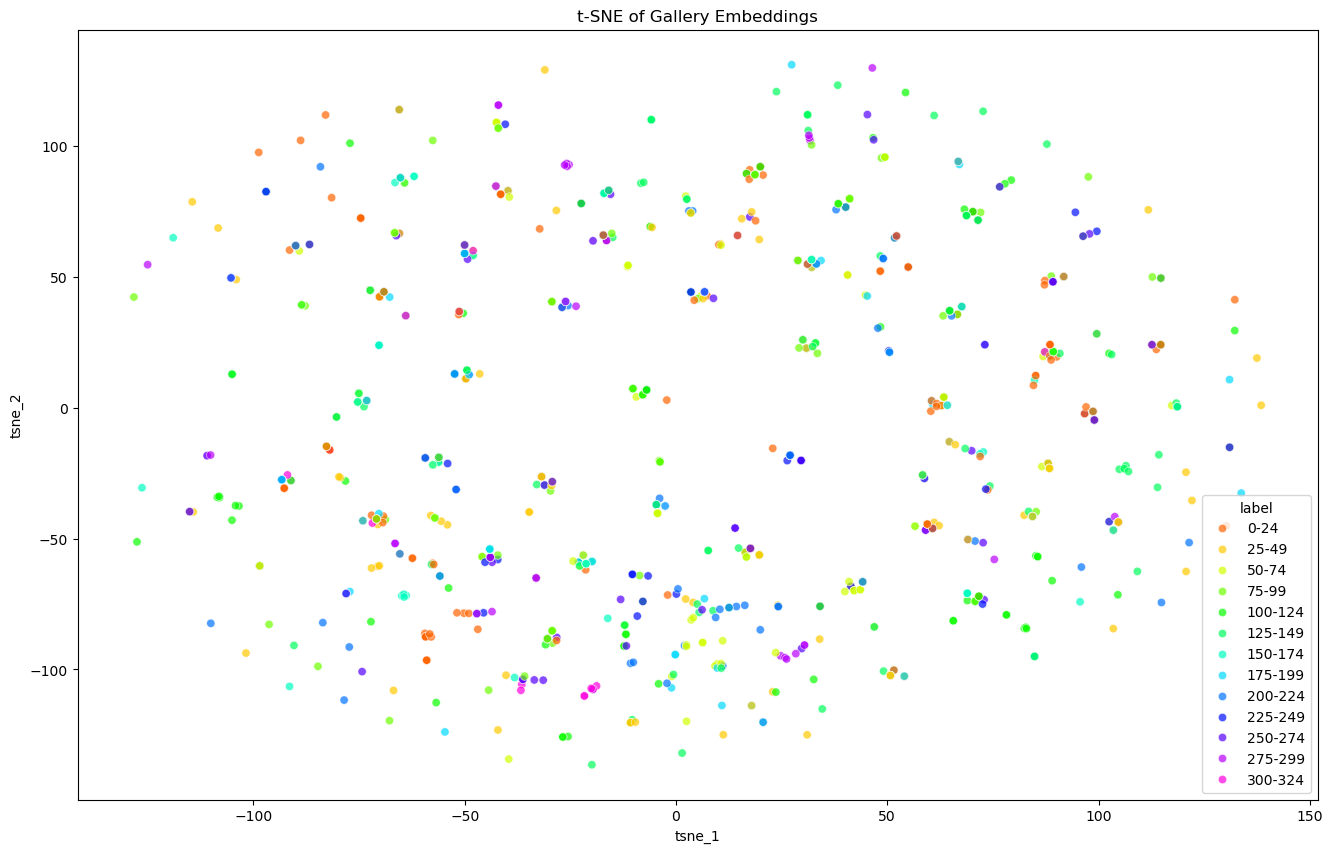

<Figure size 640x480 with 0 Axes>

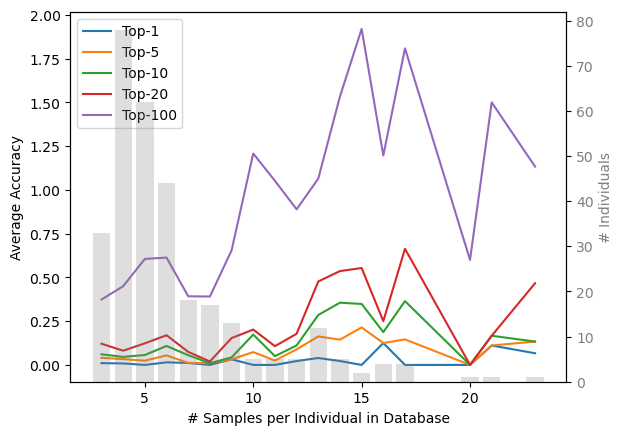

0% Correction - Recall@1: 1.90%, Recall@5: 4.57%, Recall@10: 6.55%, Recall@20: 10.13%, Recall@100: 29.17%
Retrieval with 0% Correction Hard correction-------------------------------------


/data/vision/beery/scratch/antoine/CBM_reid/methods/retrieval.py:320: UserWarning: The palette list has more values (14) than needed (13), which may not be intended.
  sns.scatterplot(


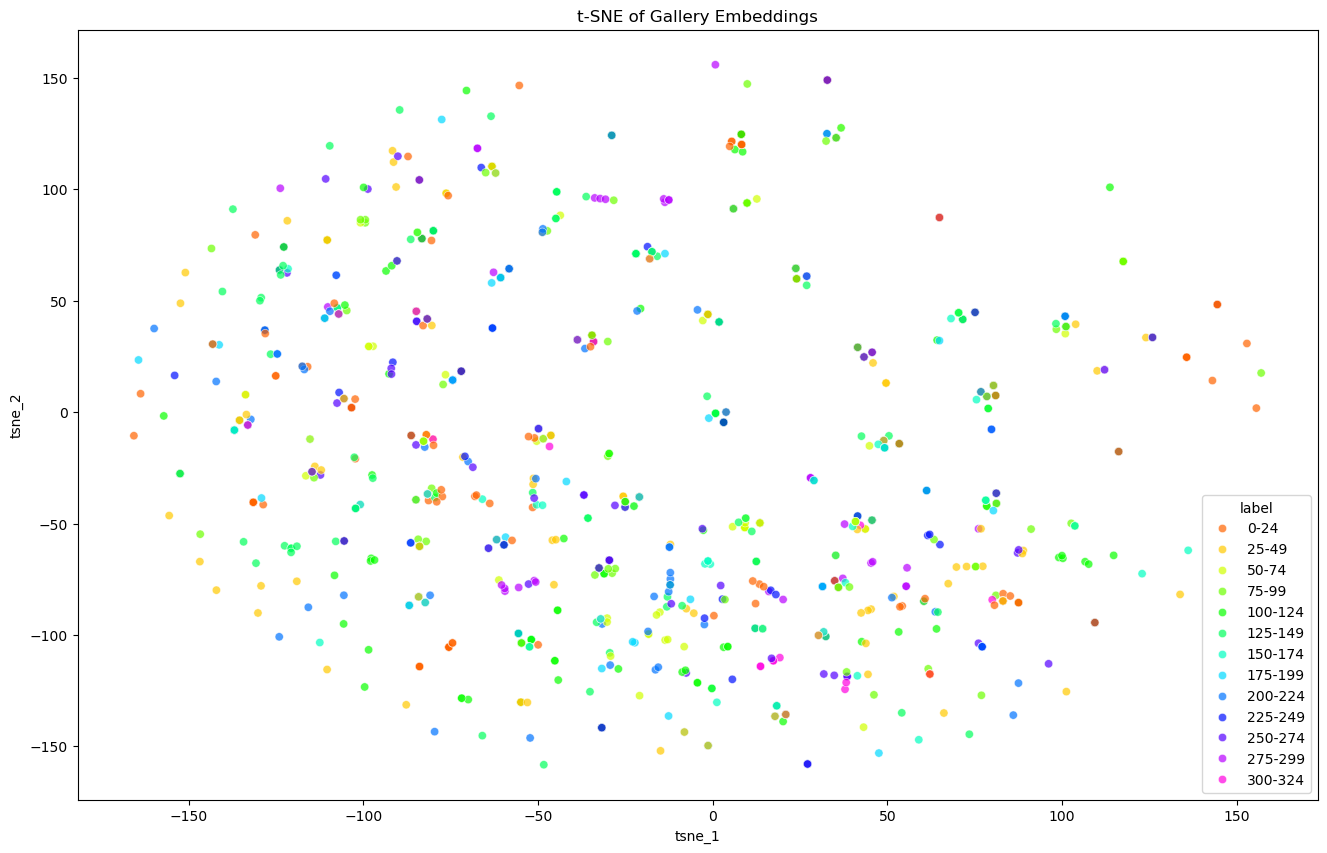

<Figure size 640x480 with 0 Axes>

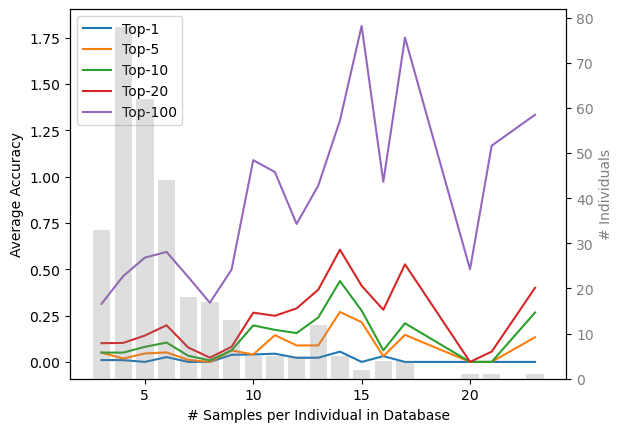

0% Correction Hard - Recall@1: 1.60%, Recall@5: 4.04%, Recall@10: 6.47%, Recall@20: 9.60%, Recall@100: 27.19%
Retrieval with 100% correction correction-------------------------------------


/data/vision/beery/scratch/antoine/CBM_reid/methods/retrieval.py:320: UserWarning: The palette list has more values (14) than needed (13), which may not be intended.
  sns.scatterplot(


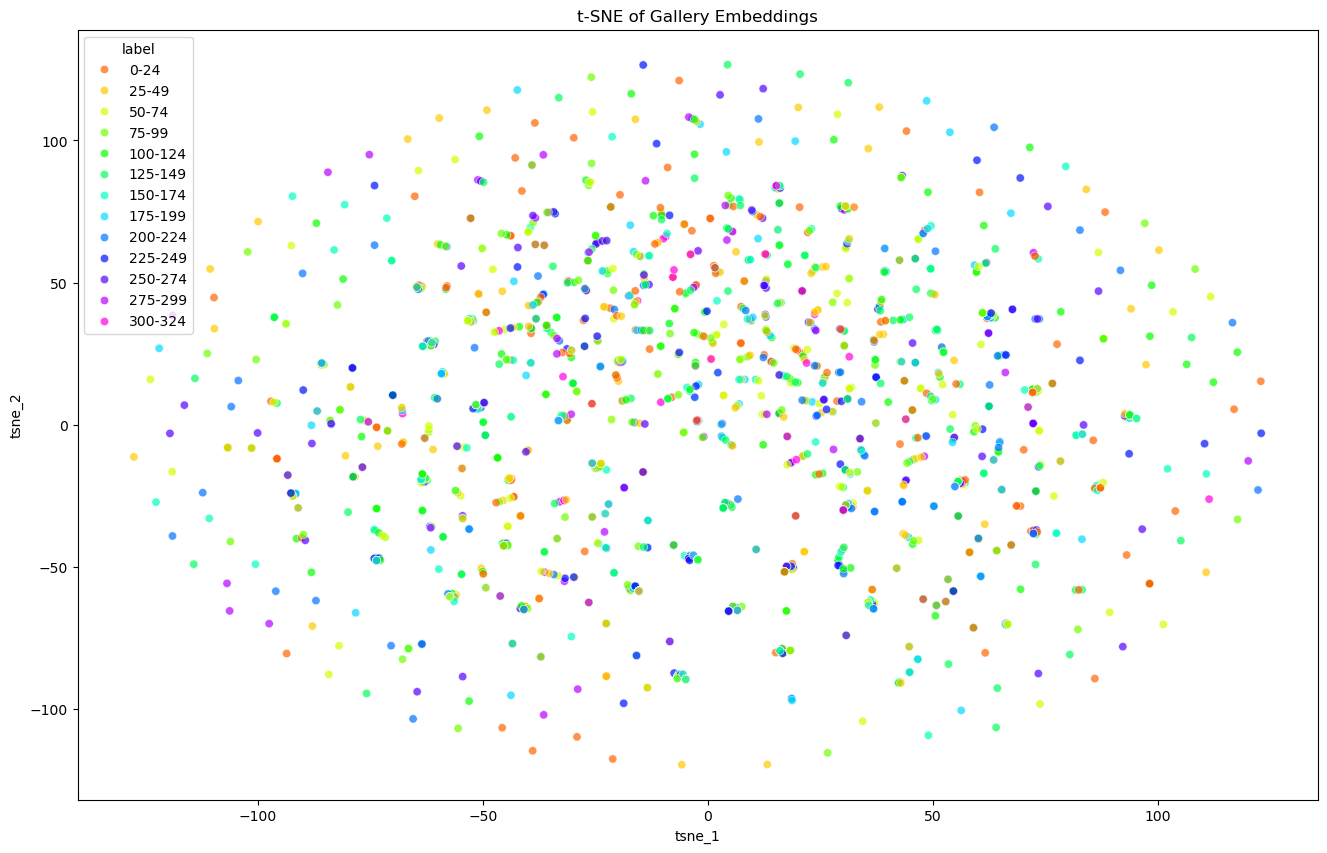

<Figure size 640x480 with 0 Axes>

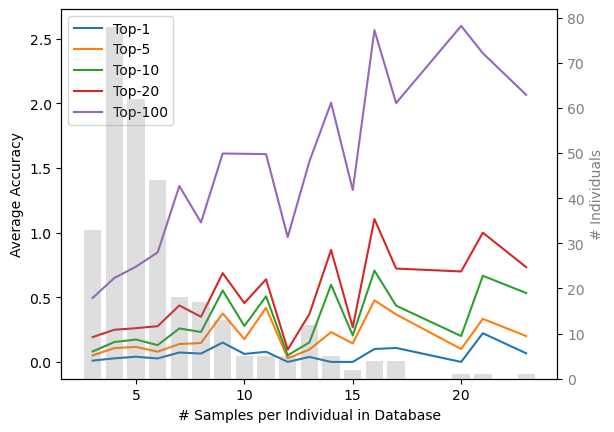

100% correction - Recall@1: 5.03%, Recall@5: 13.48%, Recall@10: 19.19%, Recall@20: 29.09%, Recall@100: 61.54%
Retrieval with Oracle correction correction-------------------------------------


/data/vision/beery/scratch/antoine/CBM_reid/methods/retrieval.py:320: UserWarning: The palette list has more values (14) than needed (13), which may not be intended.
  sns.scatterplot(


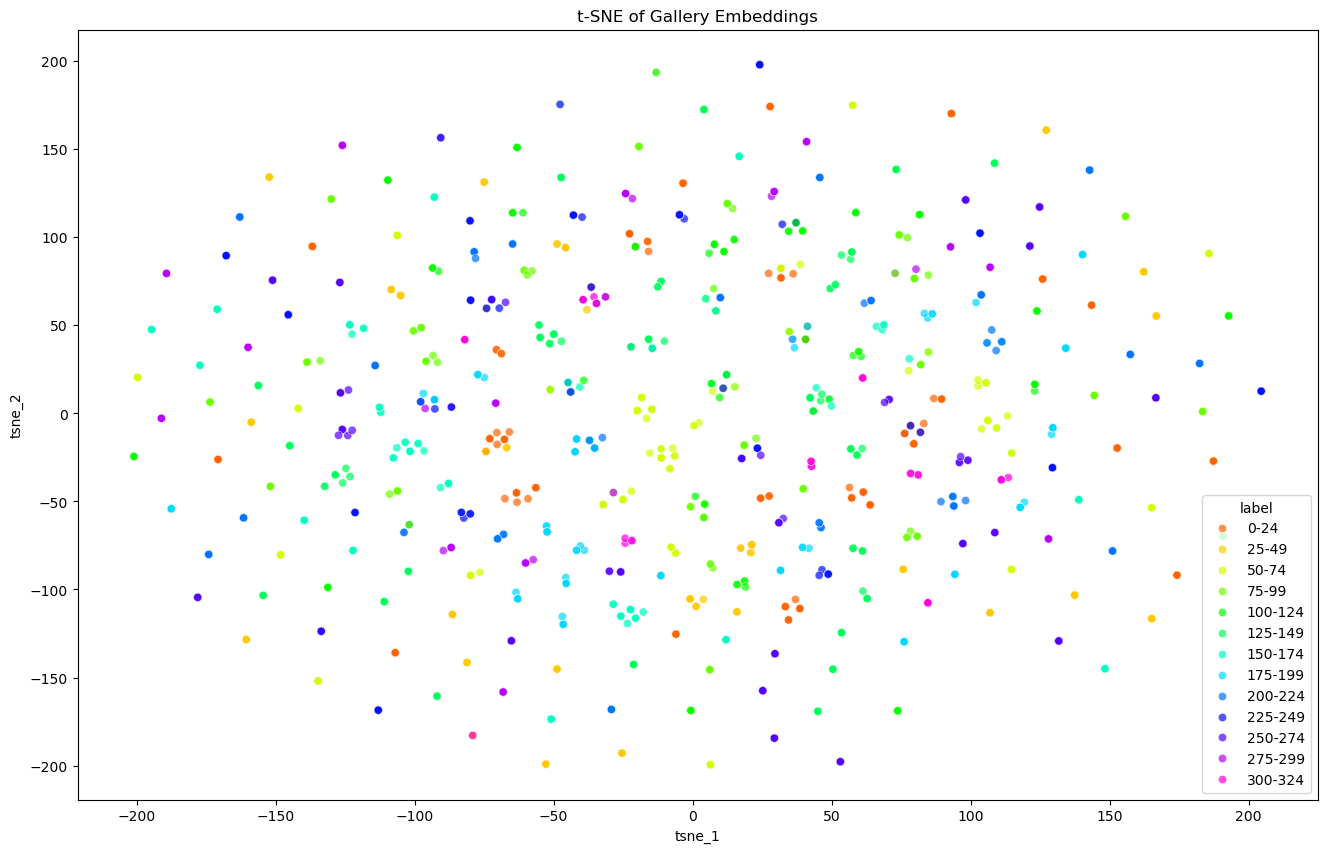

<Figure size 640x480 with 0 Axes>

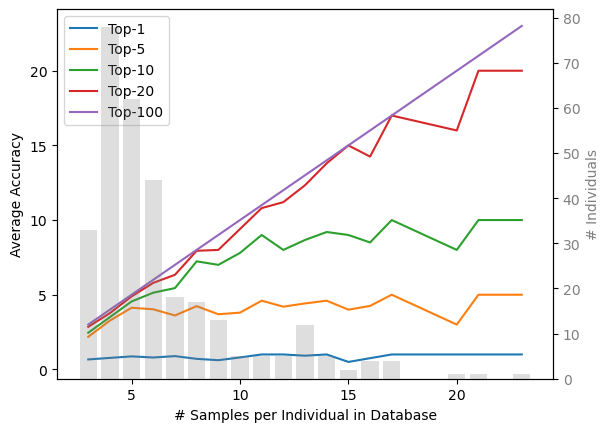

Oracle correction - Recall@1: 82.56%, Recall@5: 97.41%, Recall@10: 99.31%, Recall@20: 100.00%, Recall@100: 100.00%

Testing with seek_homemade distance:
Retrieval with 0% Correction correction-------------------------------------


/data/vision/beery/scratch/antoine/CBM_reid/methods/retrieval.py:320: UserWarning: The palette list has more values (14) than needed (13), which may not be intended.
  sns.scatterplot(


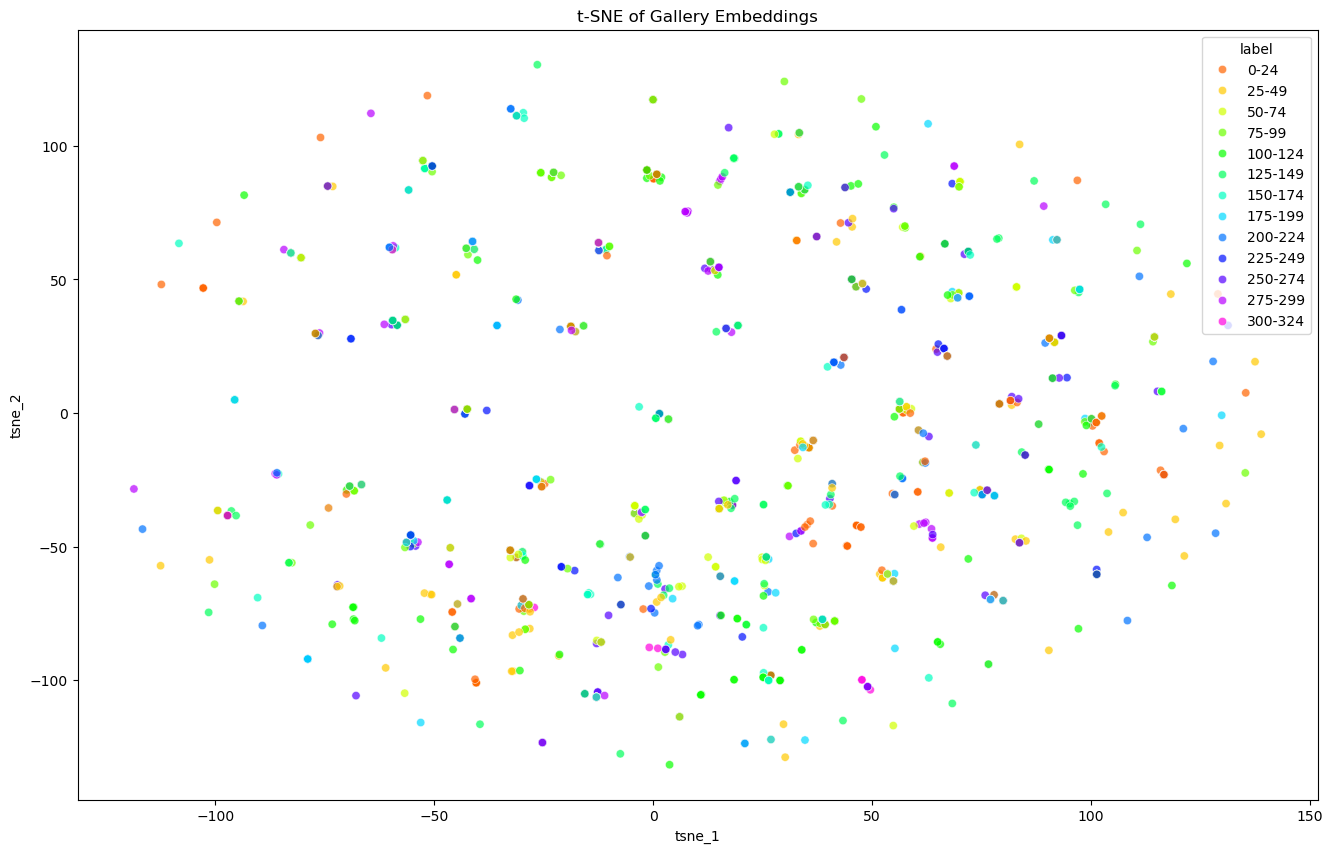

<Figure size 640x480 with 0 Axes>

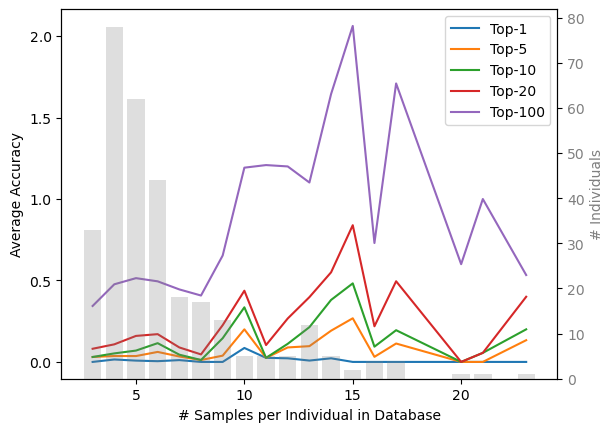

0% Correction - Recall@1: 1.07%, Recall@5: 4.49%, Recall@10: 6.55%, Recall@20: 10.59%, Recall@100: 28.18%
Retrieval with 0% Correction Hard correction-------------------------------------


/data/vision/beery/scratch/antoine/CBM_reid/methods/retrieval.py:320: UserWarning: The palette list has more values (14) than needed (13), which may not be intended.
  sns.scatterplot(


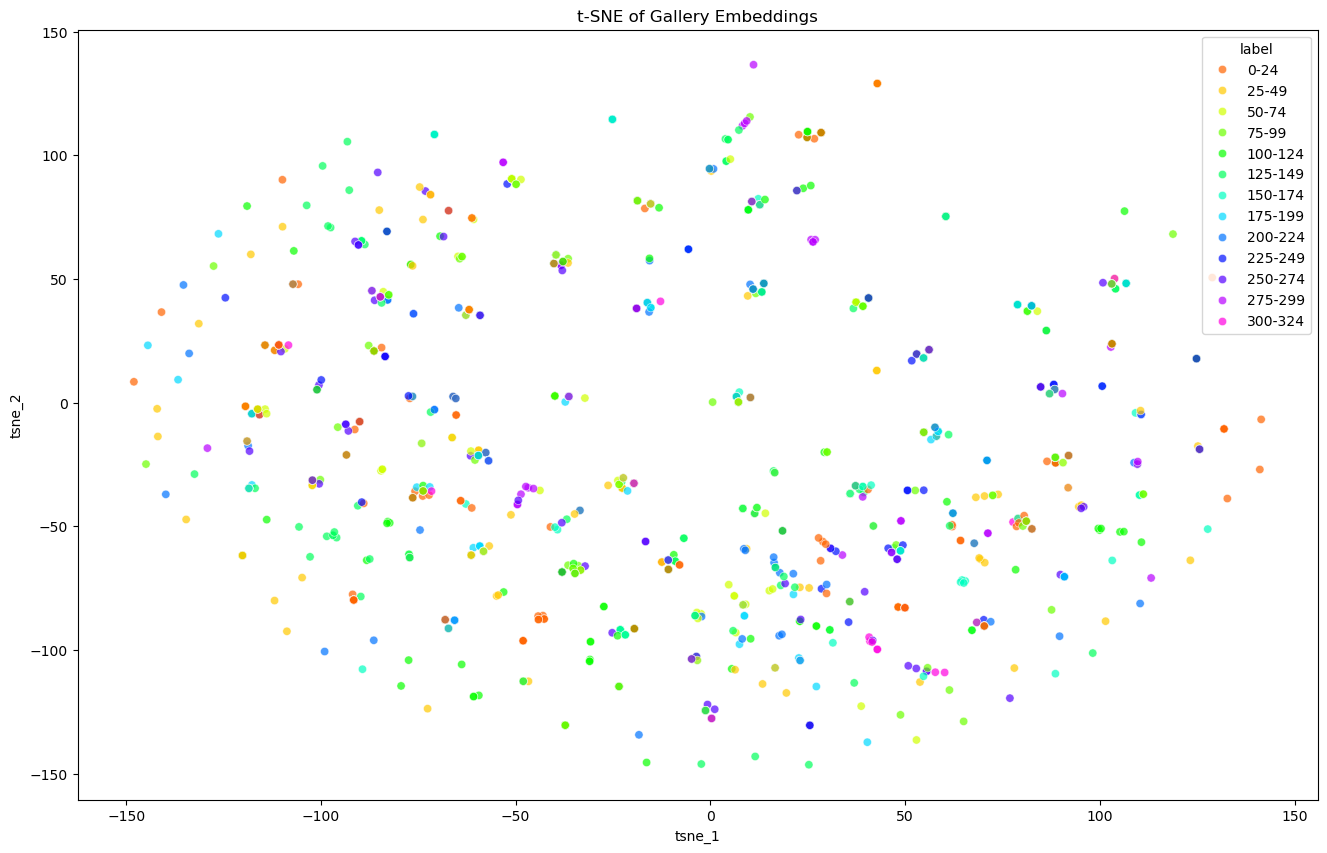

<Figure size 640x480 with 0 Axes>

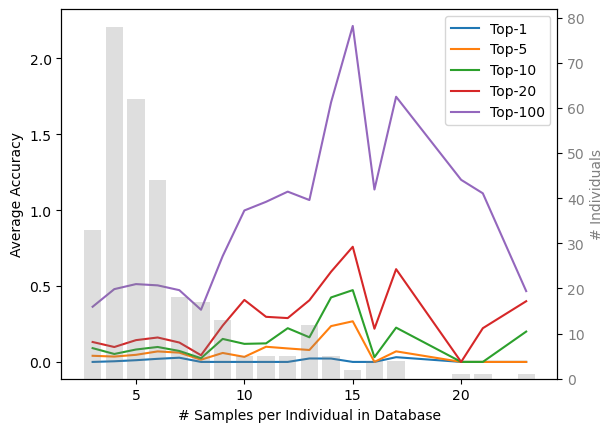

0% Correction Hard - Recall@1: 0.99%, Recall@5: 4.27%, Recall@10: 7.16%, Recall@20: 10.81%, Recall@100: 28.56%
Retrieval with 100% correction correction-------------------------------------


/data/vision/beery/scratch/antoine/CBM_reid/methods/retrieval.py:320: UserWarning: The palette list has more values (14) than needed (13), which may not be intended.
  sns.scatterplot(


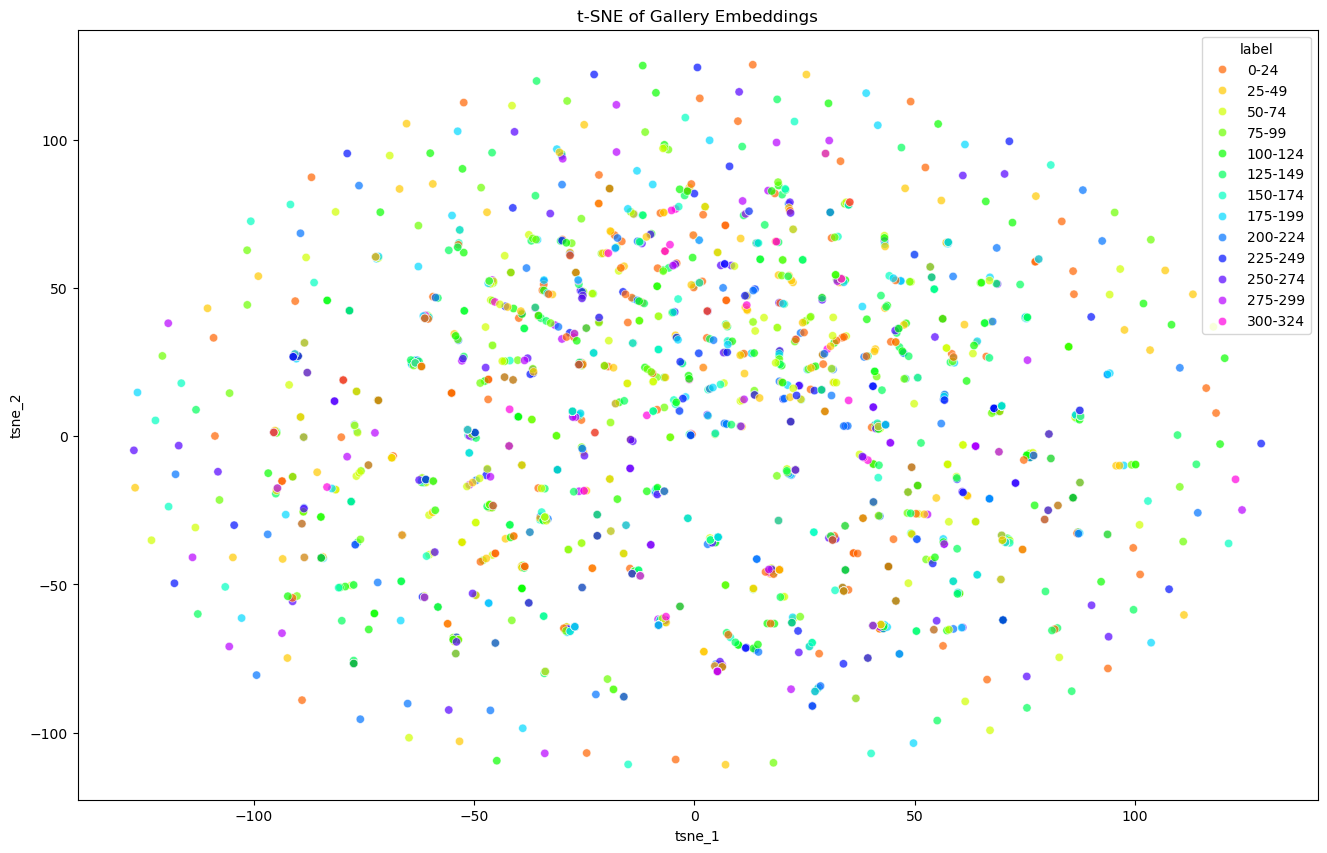

<Figure size 640x480 with 0 Axes>

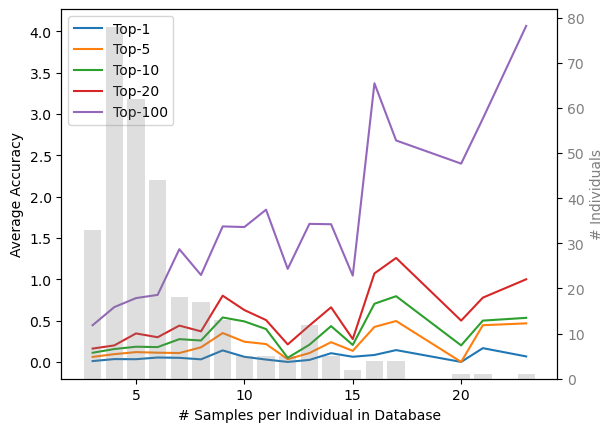

100% correction - Recall@1: 5.03%, Recall@5: 12.95%, Recall@10: 19.88%, Recall@20: 29.32%, Recall@100: 60.85%
Retrieval with Oracle correction correction-------------------------------------


/data/vision/beery/scratch/antoine/CBM_reid/methods/retrieval.py:320: UserWarning: The palette list has more values (14) than needed (13), which may not be intended.
  sns.scatterplot(


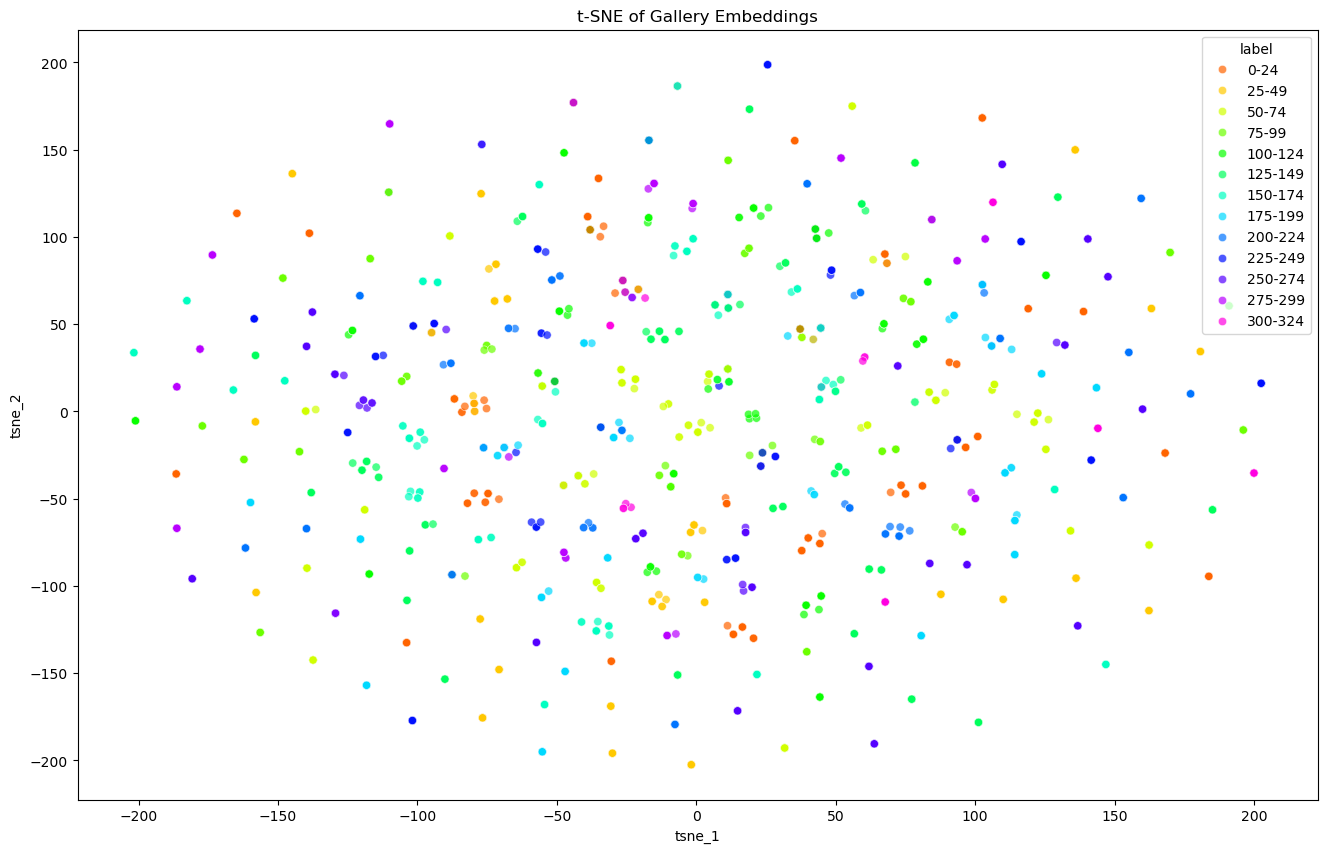

<Figure size 640x480 with 0 Axes>

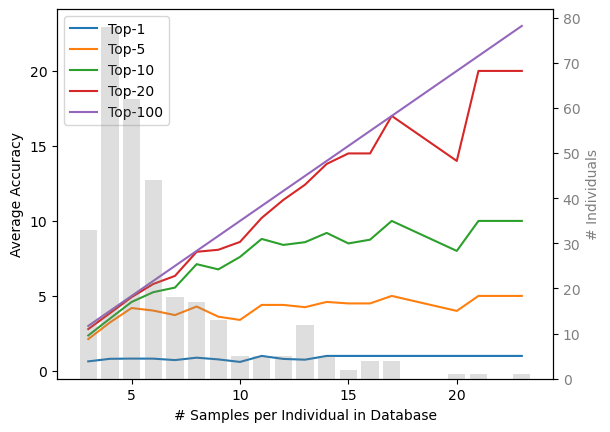

Oracle correction - Recall@1: 82.33%, Recall@5: 95.13%, Recall@10: 98.55%, Recall@20: 100.00%, Recall@100: 100.00%

Testing with seek_homemade_2 distance:
Retrieval with 0% Correction correction-------------------------------------


/data/vision/beery/scratch/antoine/CBM_reid/methods/retrieval.py:320: UserWarning: The palette list has more values (14) than needed (13), which may not be intended.
  sns.scatterplot(


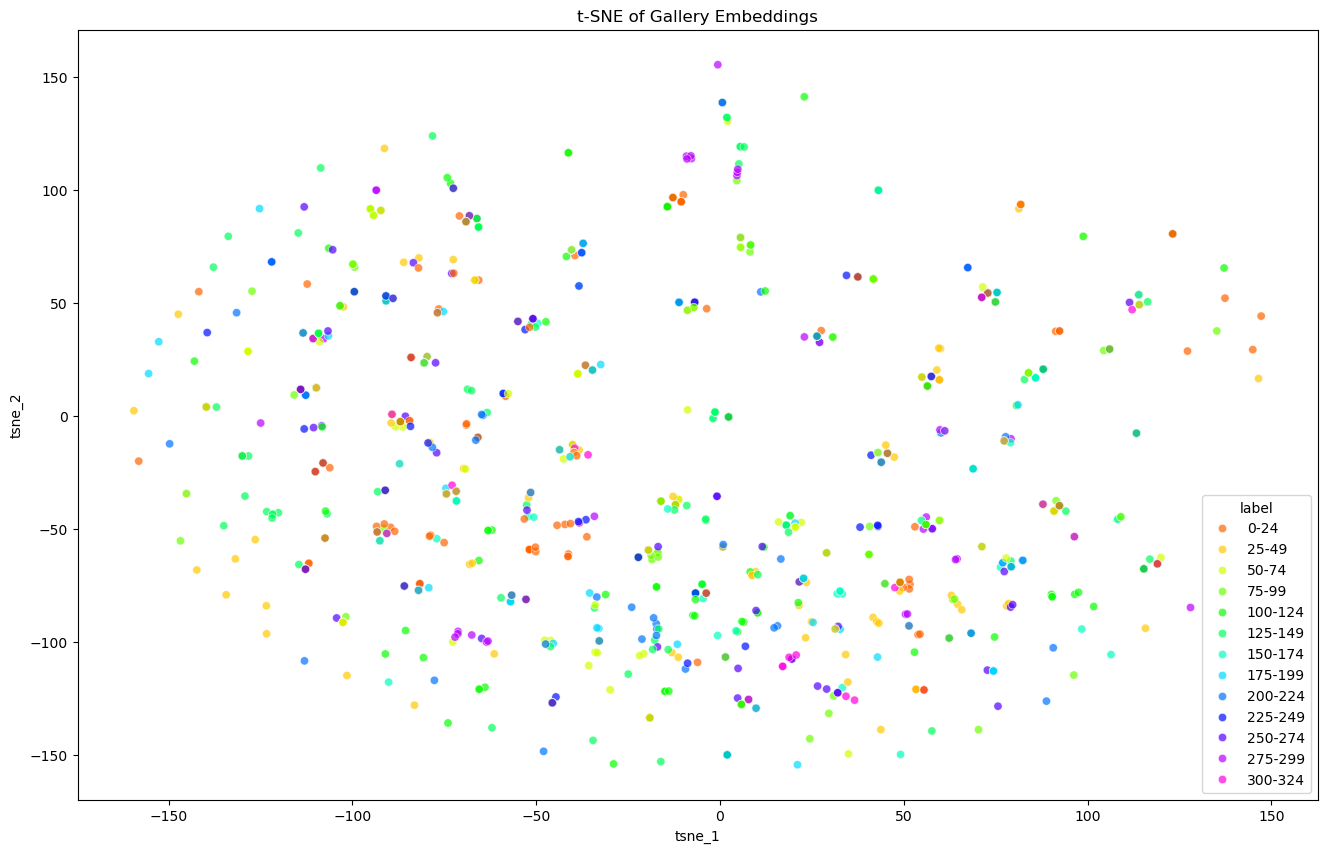

<Figure size 640x480 with 0 Axes>

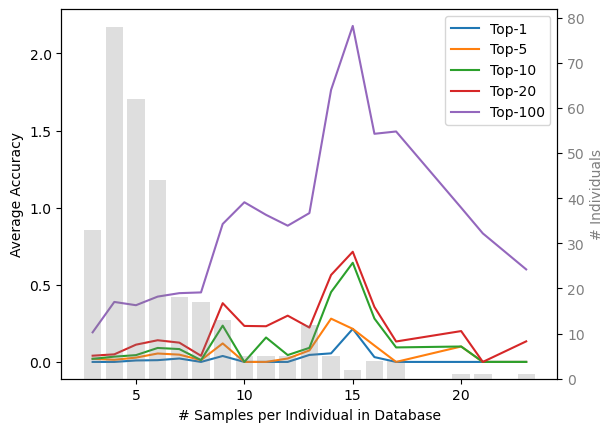

0% Correction - Recall@1: 1.52%, Recall@5: 4.34%, Recall@10: 7.69%, Recall@20: 11.88%, Recall@100: 30.08%
Retrieval with 0% Correction Hard correction-------------------------------------


/data/vision/beery/scratch/antoine/CBM_reid/methods/retrieval.py:320: UserWarning: The palette list has more values (14) than needed (13), which may not be intended.
  sns.scatterplot(


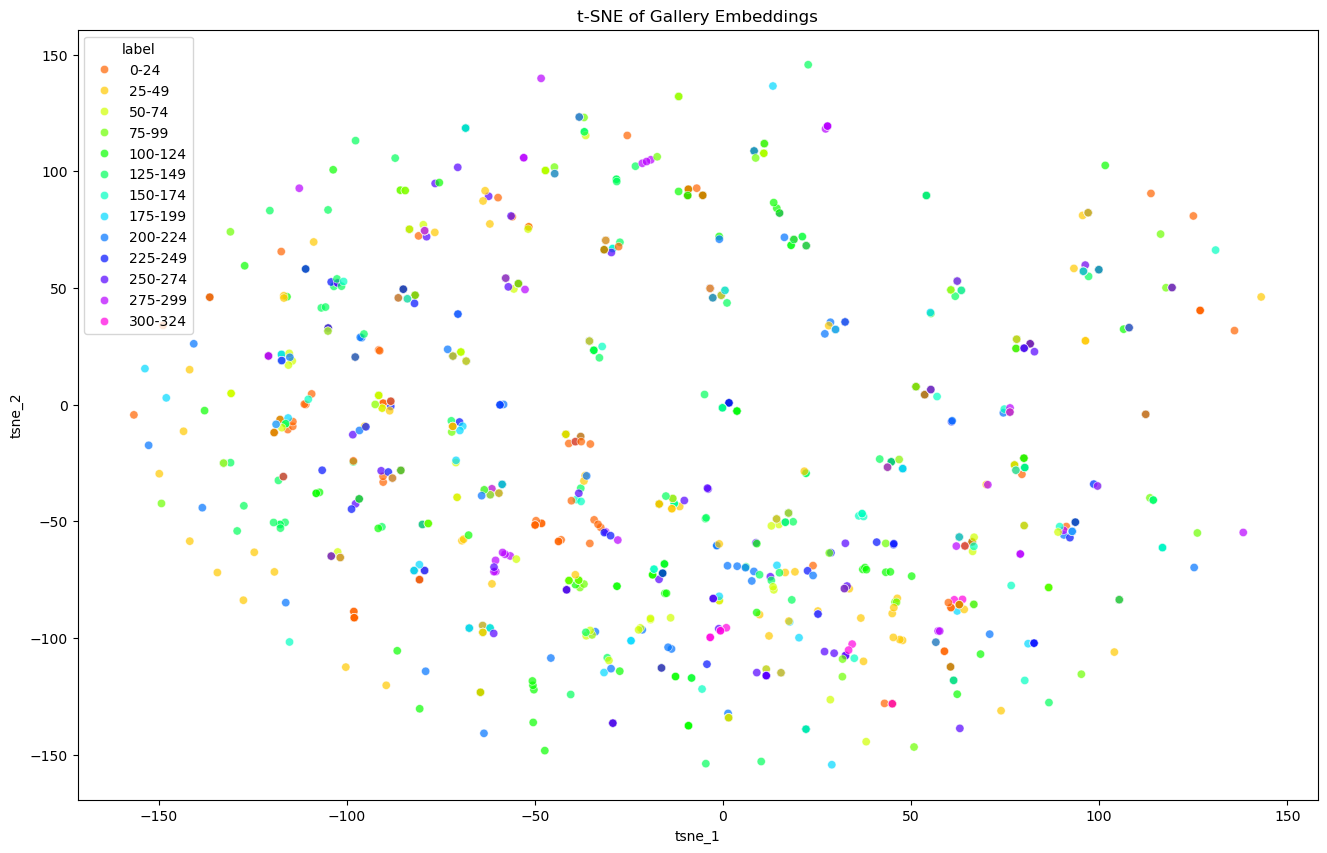

<Figure size 640x480 with 0 Axes>

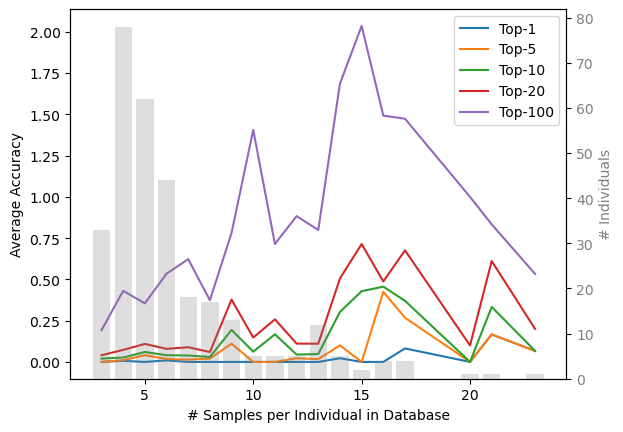

0% Correction Hard - Recall@1: 0.91%, Recall@5: 3.88%, Recall@10: 6.78%, Recall@20: 10.89%, Recall@100: 30.46%
Retrieval with 100% correction correction-------------------------------------


/data/vision/beery/scratch/antoine/CBM_reid/methods/retrieval.py:320: UserWarning: The palette list has more values (14) than needed (13), which may not be intended.
  sns.scatterplot(


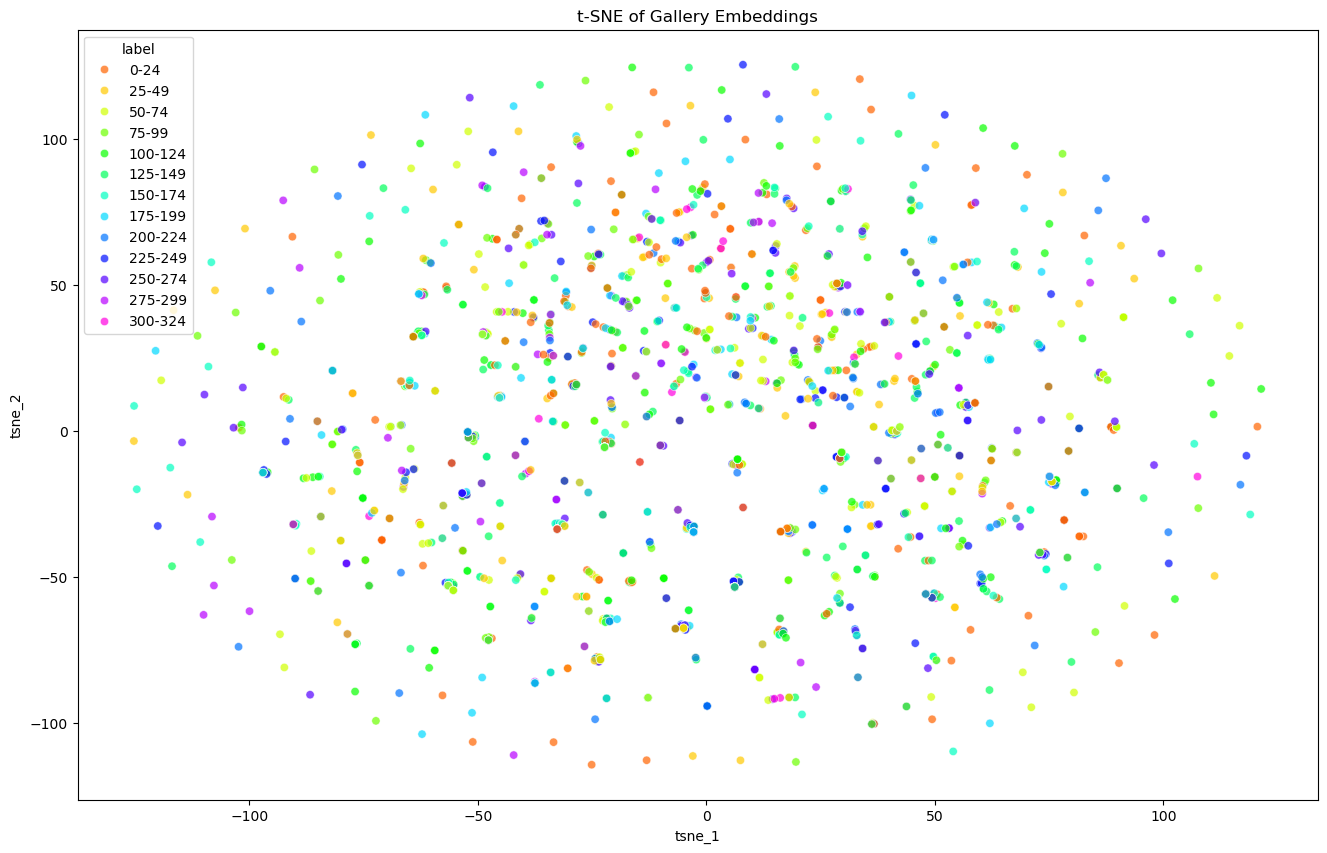

<Figure size 640x480 with 0 Axes>

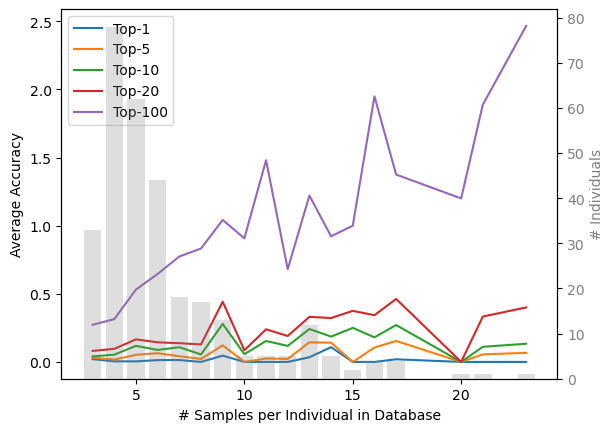

100% correction - Recall@1: 1.37%, Recall@5: 4.87%, Recall@10: 10.21%, Recall@20: 15.38%, Recall@100: 47.75%
Retrieval with Oracle correction correction-------------------------------------


/data/vision/beery/scratch/antoine/CBM_reid/methods/retrieval.py:320: UserWarning: The palette list has more values (14) than needed (13), which may not be intended.
  sns.scatterplot(


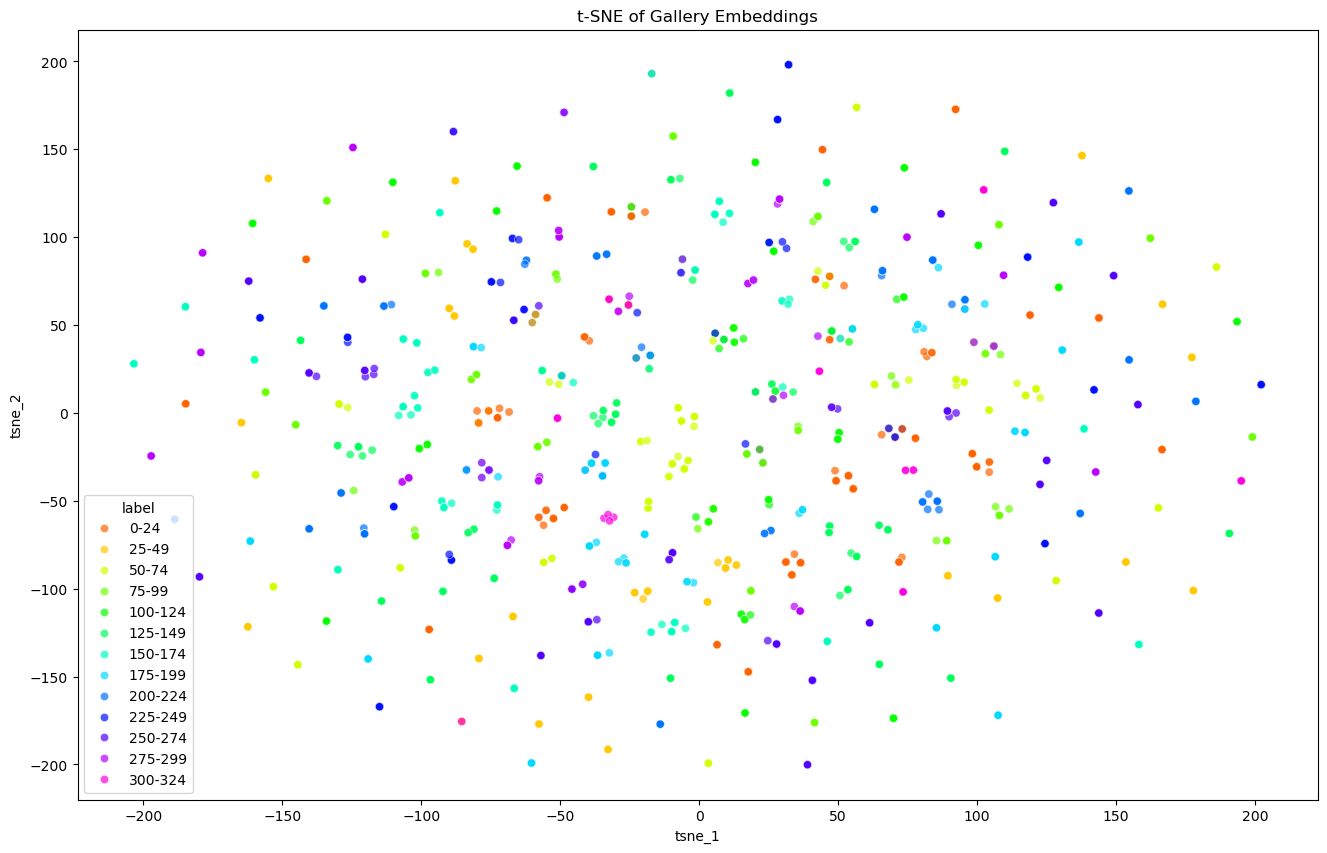

<Figure size 640x480 with 0 Axes>

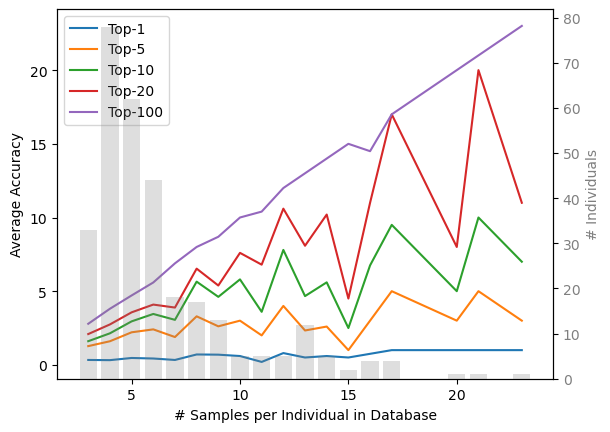

Oracle correction - Recall@1: 51.26%, Recall@5: 71.13%, Recall@10: 84.69%, Recall@20: 93.60%, Recall@100: 99.16%

Testing with seek_homemade_3 distance:
Retrieval with 0% Correction correction-------------------------------------


/data/vision/beery/scratch/antoine/CBM_reid/methods/retrieval.py:320: UserWarning: The palette list has more values (14) than needed (13), which may not be intended.
  sns.scatterplot(


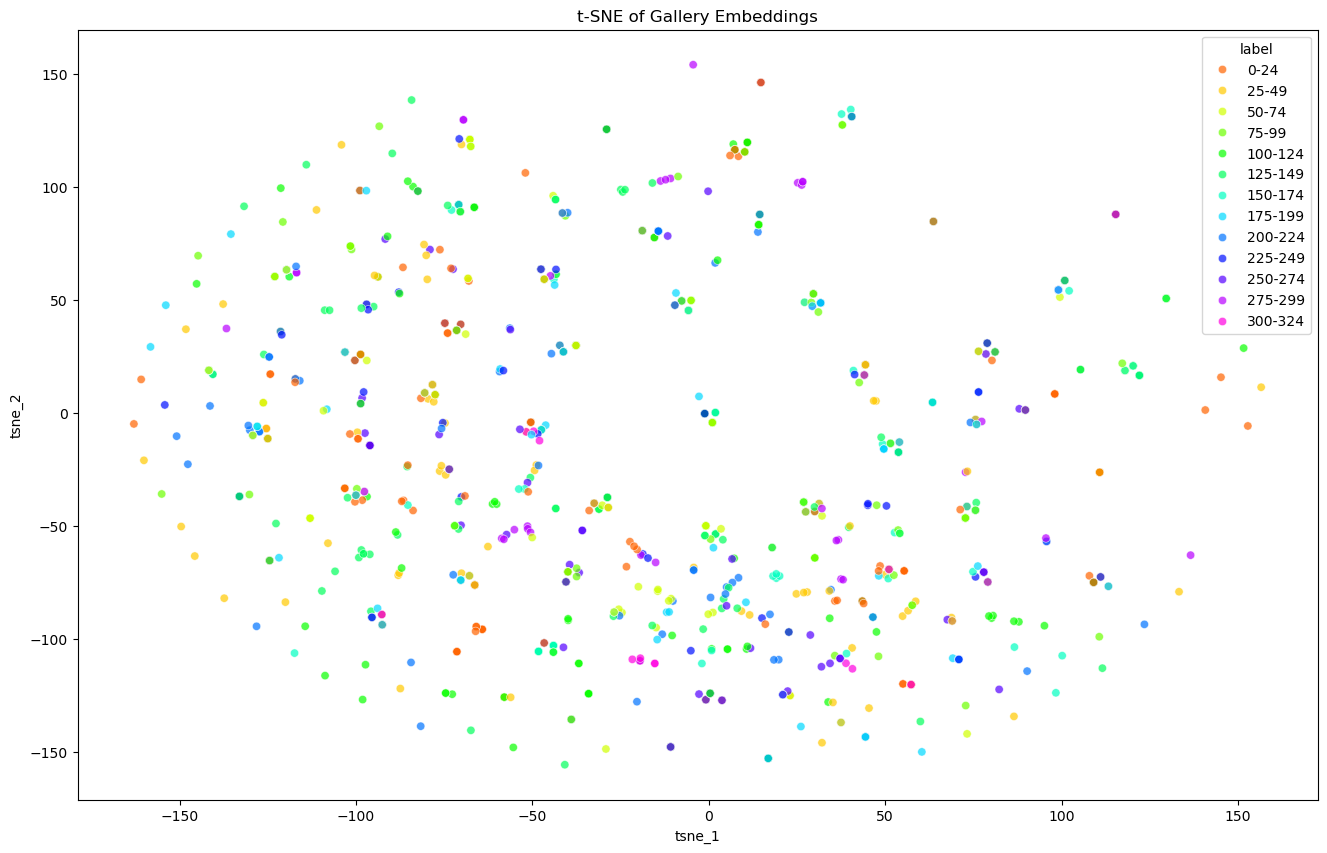

<Figure size 640x480 with 0 Axes>

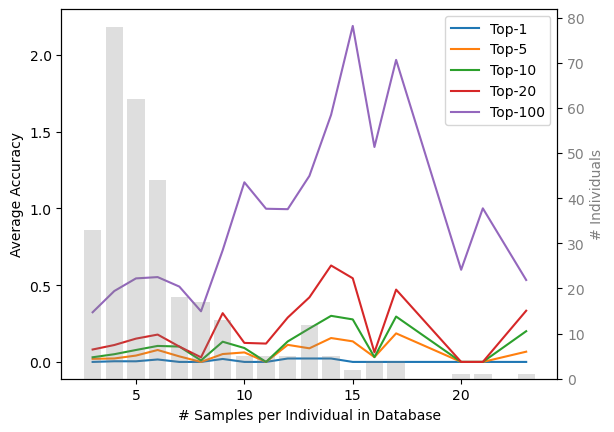

0% Correction - Recall@1: 0.69%, Recall@5: 3.81%, Recall@10: 5.41%, Recall@20: 9.14%, Recall@100: 29.02%
Retrieval with 0% Correction Hard correction-------------------------------------


/data/vision/beery/scratch/antoine/CBM_reid/methods/retrieval.py:320: UserWarning: The palette list has more values (14) than needed (13), which may not be intended.
  sns.scatterplot(


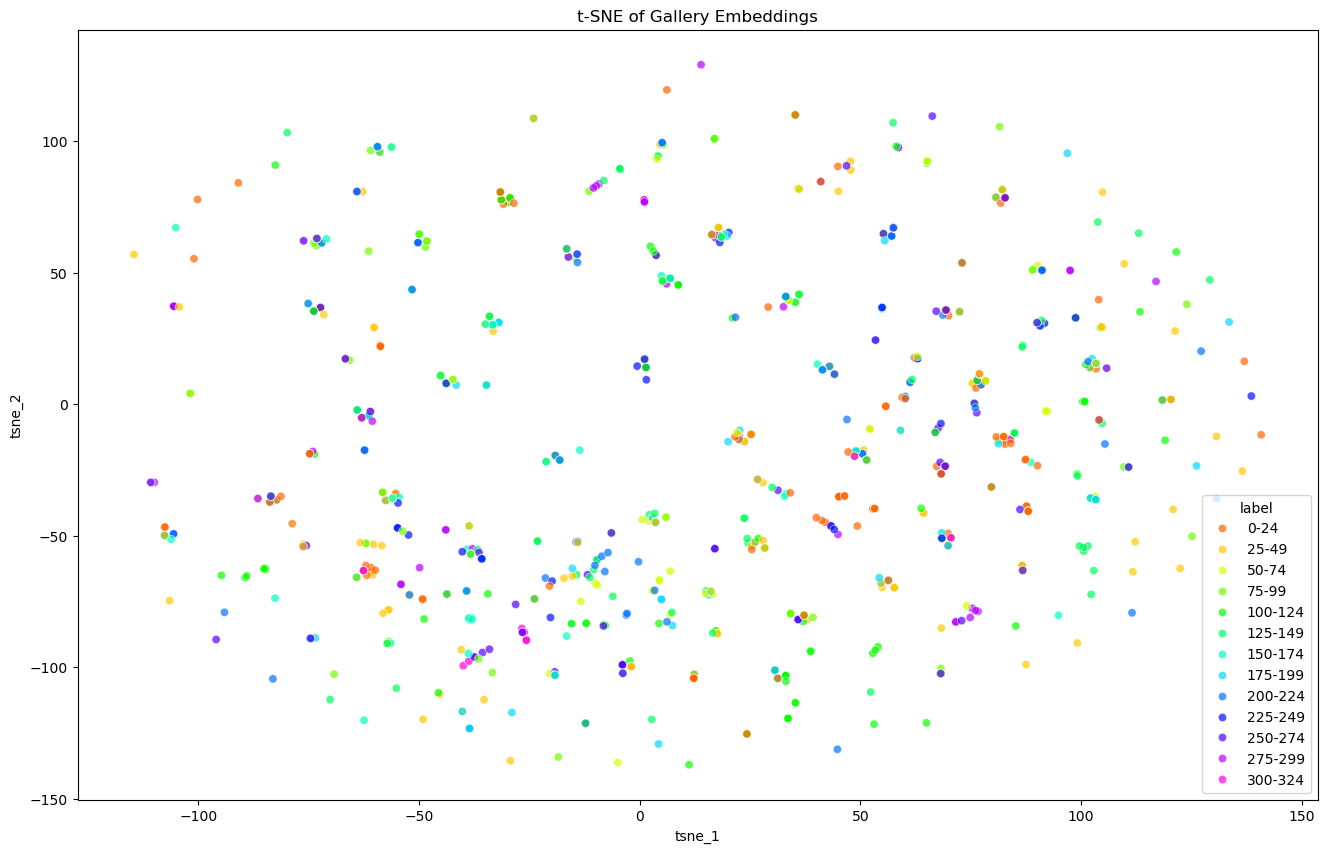

<Figure size 640x480 with 0 Axes>

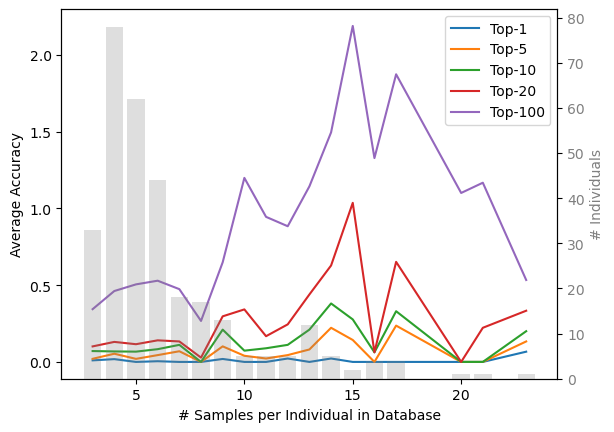

0% Correction Hard - Recall@1: 0.84%, Recall@5: 4.04%, Recall@10: 6.63%, Recall@20: 10.89%, Recall@100: 28.03%
Retrieval with 100% correction correction-------------------------------------


/data/vision/beery/scratch/antoine/CBM_reid/methods/retrieval.py:320: UserWarning: The palette list has more values (14) than needed (13), which may not be intended.
  sns.scatterplot(


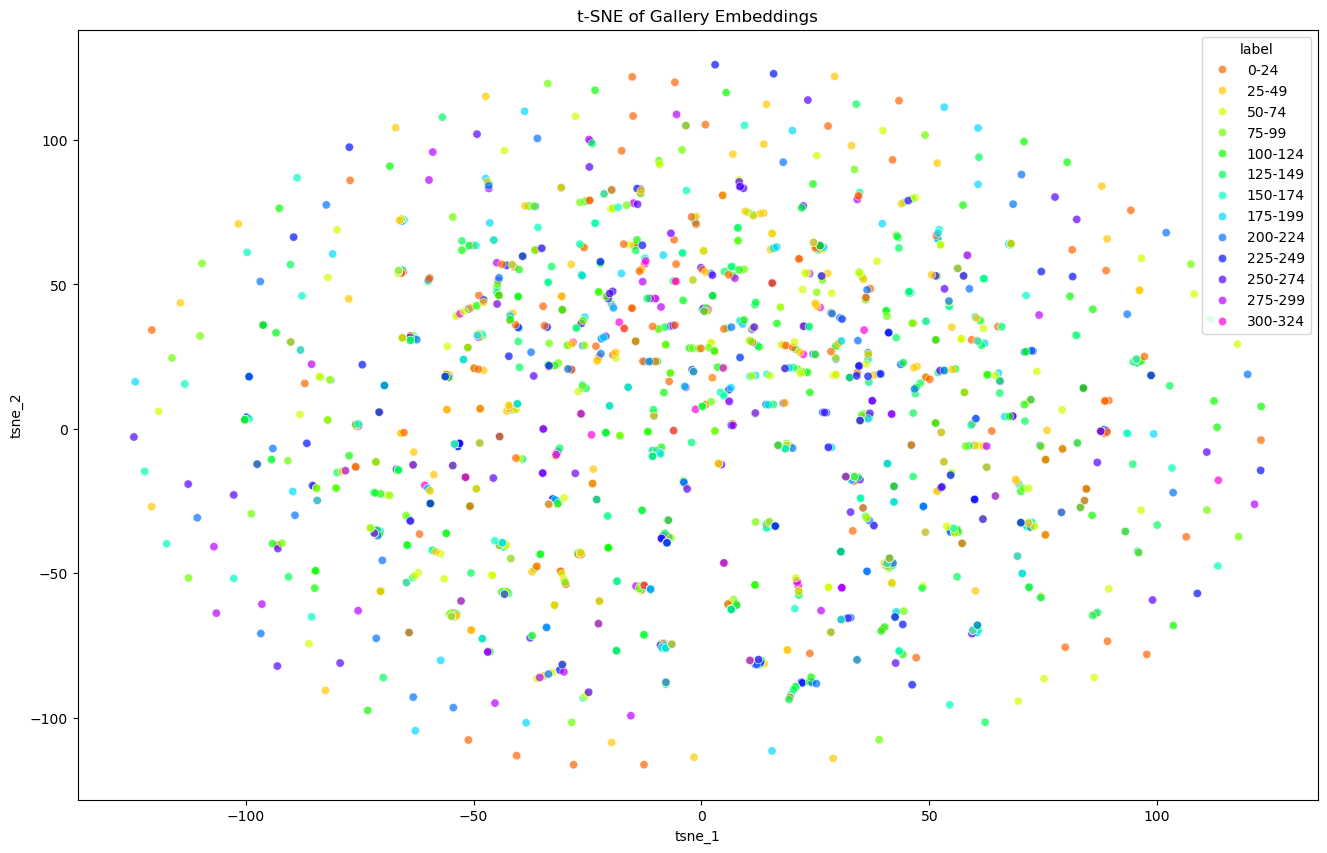

<Figure size 640x480 with 0 Axes>

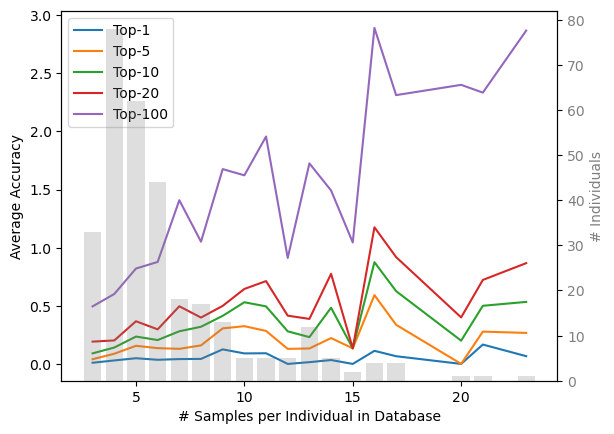

100% correction - Recall@1: 4.42%, Recall@5: 13.56%, Recall@10: 20.94%, Recall@20: 29.40%, Recall@100: 61.08%
Retrieval with Oracle correction correction-------------------------------------


/data/vision/beery/scratch/antoine/CBM_reid/methods/retrieval.py:320: UserWarning: The palette list has more values (14) than needed (13), which may not be intended.
  sns.scatterplot(


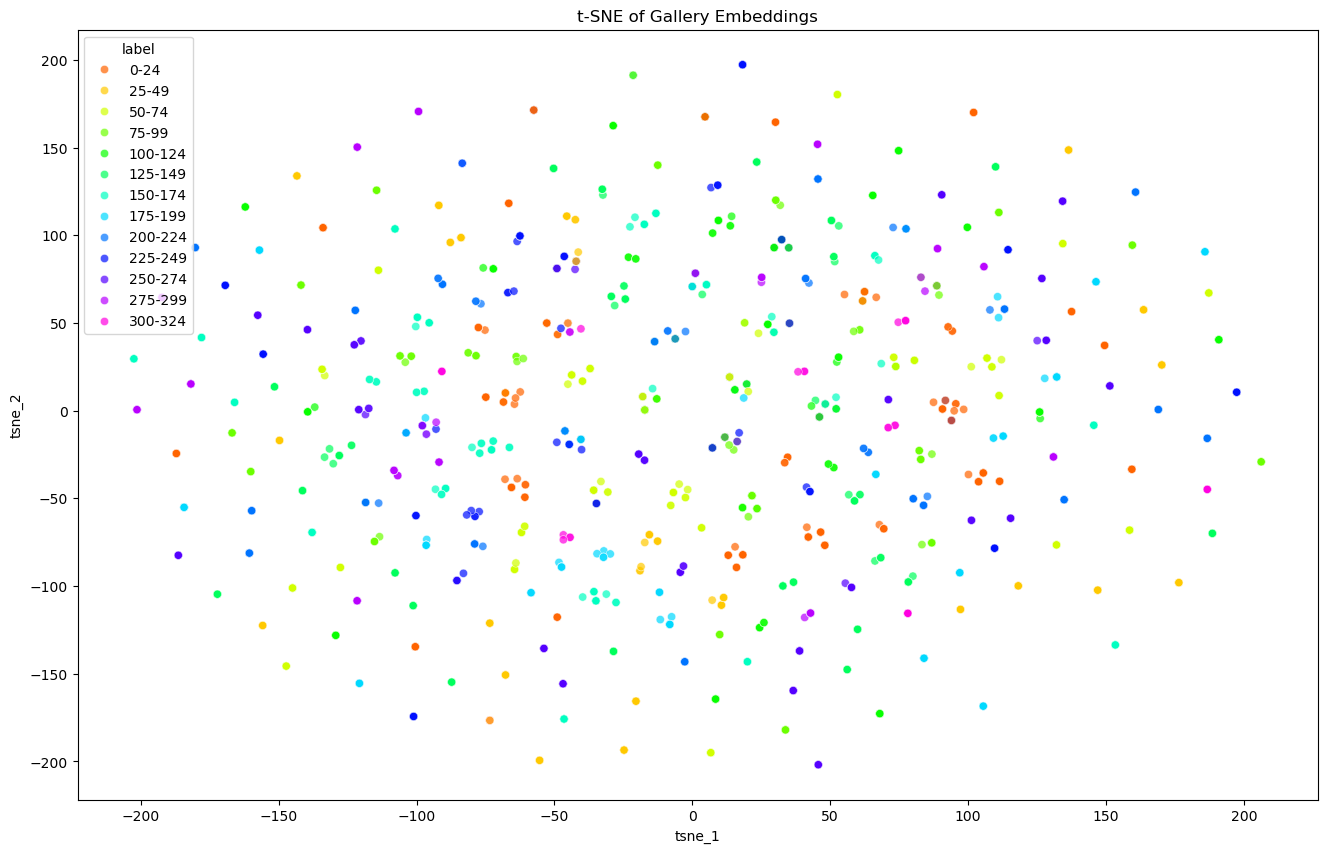

<Figure size 640x480 with 0 Axes>

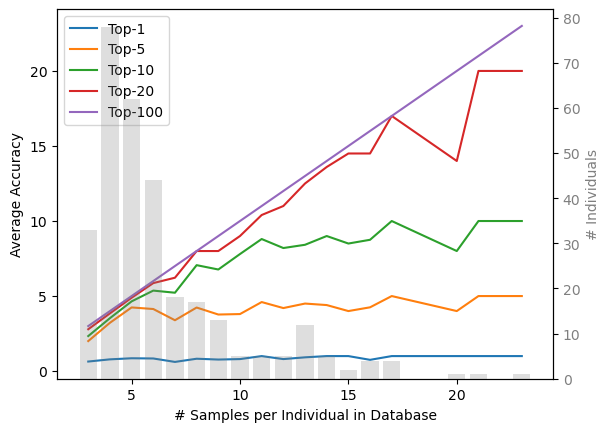

Oracle correction - Recall@1: 82.94%, Recall@5: 96.04%, Recall@10: 98.25%, Recall@20: 100.00%, Recall@100: 100.00%


{'0% Correction_cosine_sim': {1: 0.01904036557501904,
  5: 0.0456968773800457,
  10: 0.0654988575780655,
  20: 0.1012947448591013,
  100: 0.2916984006092917},
 '0% Correction Hard_cosine_sim': {1: 0.015993907083015995,
  5: 0.04036557501904037,
  10: 0.06473724295506474,
  20: 0.09596344249809596,
  100: 0.2718964204112719},
 '100% correction_cosine_sim': {1: 0.05026656511805026,
  5: 0.13480578827113482,
  10: 0.19192688499619193,
  20: 0.2909367859862909,
  100: 0.6153846153846154},
 'Oracle correction_cosine_sim': {1: 0.8255902513328256,
  5: 0.9741051028179741,
  10: 0.9931454683929931,
  20: 1.0,
  100: 1.0},
 '0% Correction_seek_homemade': {1: 0.010662604722010662,
  5: 0.04493526275704494,
  10: 0.0654988575780655,
  20: 0.10586443259710586,
  100: 0.2817974105102818},
 '0% Correction Hard_seek_homemade': {1: 0.009900990099009901,
  5: 0.04265041888804265,
  10: 0.0715917745620716,
  20: 0.10814927646610815,
  100: 0.2856054836252856},
 '100% correction_seek_homemade': {1: 0.050

In [3]:
code = '[debug5epochs]CBM'

MD_for_concepts = Backbone(model_name="MegaDescriptor", pretraining="backbone_for_concepts_w", experiment_code=code)
concept_head = ConceptHeadTunneled(loss=categorical_CE_loss, experiment_code = code, layer = CrossedHeadNN(), reset_weights=False)

# Freeze other models and unfreeze the projector
MD_for_concepts.freeze()
concept_head.freeze()

test_intervention_fns = {
    "0% Correction": None,
    "0% Correction Hard": SEEK.hard,
    "100% correction": SEEK.perfect_correction,
    "Oracle correction": SEEK.oracle_correction
}

# Run the structured test method
concept_head.retrieval_test(
    backbone_for_concepts=MD_for_concepts, 
    train_loader=train_loader, 
    test_loader=test_loader, 
    intervention_fns=test_intervention_fns
)

## Exp 1 : Projector replicates without any correction

For 100 epochs, I train without any correction at trainning time and I test it under several correction policies.

In [ ]:
code = '[prep_100epochs]STEP_4_exp_1_training_under_no_correction'

MD_for_concepts = Backbone(model_name="MegaDescriptor", pretraining="backbone_for_concepts_w", experiment_code=code)
MD_finedtuned = Backbone(model_name="MegaDescriptor", pretraining="savannah_elephants", experiment_code=code)
pr = Projector(loss_type ='ArcFace', lr=5e-6, scale=64, margin=0.5, experiment_code=code, intervention_fn=None, alpha = 0.5)
concept_head = ConceptHeadTunneled(loss=categorical_CE_loss, experiment_code = code, layer = CrossedHeadNN(), reset_weights=False)

# Freeze other models and unfreeze the projector
MD_for_concepts.freeze()
MD_finedtuned.unfreeze()
concept_head.freeze()
pr.unfreeze()

# Train the model
pr.train(
    train_loader, 
    test_loader, 
    backbone_for_concepts=MD_for_concepts, 
    backbone=MD_finedtuned, 
    concept_head=concept_head, 
    num_epochs=100)

# Define intervention functions for testing
test_intervention_fns = {
    "100% Correction": SEEK.oracle_correction,
    "50% Correction + soft": SEEK.correct_or_soft,
    "50% Correction + hard": SEEK.correct_or_hard,
    "0% Correction": None,
    "0% Correction Hard": SEEK.hard
}

# Run the structured test method
pr.test(
    backbone_for_concepts=MD_for_concepts, 
    backbone=MD_finedtuned, 
    concept_head=concept_head, 
    train_loader=train_loader, 
    test_loader=test_loader, 
    intervention_fns=test_intervention_fns
)

/data/vision/beery/scratch/antoine/CBM_reid/methods/backbone.py:34: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  
wandb: Currently logged in as: antoinesalaun (antoinesalau

/data/vision/beery/scratch/antoine/CBM_reid/methods/concept_head_tunneled.py:388: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  self.load_state_dict(torch.load(path, map_loc

Model loaded from /data/vision/beery/scratch/antoine/CBM_reid/weights/concept_w.pt
loading weights for the concept head
Parameters requiring gradients - Projector: True, Backbone_for_concepts: False, Backbone: True, Concept_head: False
Embeddings norm: 47.54322052001953, Projected concepts norm: 56.116249084472656
Epoch 1/100 | Loss: 7.0877 | Batch R@1: 1.41% | Train: R@1=16.2% R@5=31.5% R@20=49.7% R@100=71.6% | Val: R@1=15.8% R@5=24.4% R@10=28.9% R@20=35.3% R@100=54.2%
Embeddings norm: 46.544376373291016, Projected concepts norm: 56.00010681152344
Embeddings norm: 45.53883743286133, Projected concepts norm: 57.59544372558594
Embeddings norm: 50.57598876953125, Projected concepts norm: 57.012107849121094
Embeddings norm: 52.73237609863281, Projected concepts norm: 56.87224197387695
Embeddings norm: 53.51953887939453, Projected concepts norm: 56.33009719848633
Epoch 6/100 | Loss: 6.3727 | Batch R@1: 1.31% | Train: R@1=13.4% R@5=26.4% R@20=43.7% R@100=68.5% | Val: R@1=21.1% R@5=29.7% R@1

{'100% Correction': {1: 0.3373952779893374,
  5: 0.44935262757044936,
  10: 0.5277989337395278,
  20: 0.6054836252856055,
  100: 0.8271134805788272},
 '50% Correction + soft': {1: 0.2361005331302361,
  5: 0.357958872810358,
  10: 0.4166031987814166,
  20: 0.5133282559025133,
  100: 0.7227722772277227},
 '50% Correction + hard': {1: 0.31987814166031986,
  5: 0.43869002284843867,
  10: 0.5087585681645087,
  20: 0.5864432597105864,
  100: 0.8118811881188119},
 '0% Correction': {1: 0.27646610814927647,
  5: 0.39375476009139376,
  10: 0.45544554455445546,
  20: 0.5323686214775324,
  100: 0.7197258187357197},
 '0% Correction Hard': {1: 0.3175932977913176,
  5: 0.43412033511043413,
  10: 0.5064737242955065,
  20: 0.5826351865955827,
  100: 0.8080731150038081}}

In [3]:
code = '[debug5epochs]STEP_4_exp_1_training_under_no_correction'

MD_for_concepts = Backbone(model_name="MegaDescriptor", pretraining="backbone_for_concepts_w", experiment_code=code)
MD_finedtuned = Backbone(model_name="MegaDescriptor", pretraining="savannah_elephants", experiment_code=code)
pr = Projector(loss_type ='ArcFace', lr=5e-6, scale=64, margin=0.5, experiment_code=code, intervention_fn=None, alpha = 0.5)
concept_head = ConceptHeadTunneled(loss=categorical_CE_loss, experiment_code = code, layer = CrossedHeadNN(), reset_weights=False)

# Freeze other models and unfreeze the projector
MD_for_concepts.freeze()
MD_finedtuned.unfreeze()
concept_head.freeze()
pr.unfreeze()

# Train the model
pr.train(
    train_loader, 
    test_loader, 
    backbone_for_concepts=MD_for_concepts, 
    backbone=MD_finedtuned, 
    concept_head=concept_head, 
    num_epochs=5)

# Define intervention functions for testing
test_intervention_fns = {
    "100% Correction": SEEK.oracle_correction,
    "50% Correction + soft": SEEK.correct_or_soft,
    "50% Correction + hard": SEEK.correct_or_hard,
    "0% Correction": None,
    "0% Correction Hard": SEEK.hard
}

# Run the structured test method
pr.test(
    backbone_for_concepts=MD_for_concepts, 
    backbone=MD_finedtuned, 
    concept_head=concept_head, 
    train_loader=train_loader, 
    test_loader=test_loader, 
    intervention_fns=test_intervention_fns)

/data/vision/beery/scratch/antoine/CBM_reid/methods/backbone.py:34: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load(weight_path, map_location=self.devi

/data/vision/beery/scratch/antoine/CBM_reid/methods/concept_head_tunneled.py:388: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  self.load_state_dict(torch.load(path, map_loc

Model loaded from /data/vision/beery/scratch/antoine/CBM_reid/weights/concept_w.pt
loading weights for the concept head
Epoch 1/5 | Loss: 7.0866 | Batch R@1: 1.46% | Train: R@1=15.5% R@5=31.3% R@20=48.5% R@100=70.8% | Val: R@1=16.2% R@5=25.1% R@10=30.5% R@20=35.8% R@100=56.1%
new best weights
Epoch 2/5 | Loss: 6.8371 | Batch R@1: 0.91% | Train: R@1=15.3% R@5=29.8% R@20=47.7% R@100=70.5% | Val: R@1=17.7% R@5=26.2% R@10=31.4% R@20=36.7% R@100=57.0%
new best weights
Epoch 3/5 | Loss: 6.6444 | Batch R@1: 1.16% | Train: R@1=13.6% R@5=27.6% R@20=46.6% R@100=69.7% | Val: R@1=18.7% R@5=26.6% R@10=32.1% R@20=37.9% R@100=58.0%
new best weights
Epoch 4/5 | Loss: 6.5221 | Batch R@1: 1.01% | Train: R@1=13.0% R@5=25.9% R@20=44.3% R@100=68.0% | Val: R@1=19.9% R@5=28.6% R@10=32.3% R@20=38.9% R@100=60.1%
new best weights
Epoch 5/5 | Loss: 6.4342 | Batch R@1: 1.62% | Train: R@1=12.9% R@5=25.0% R@20=44.0% R@100=68.6% | Val: R@1=20.5% R@5=29.8% R@10=33.3% R@20=40.1% R@100=60.4%
new best weights
Retrieval 

{'100% Correction': {1: 0.26428027418126426,
  5: 0.37928408225437926,
  10: 0.44097486671744096,
  20: 0.5072353389185073,
  100: 0.718964204112719},
 '50% Correction + soft': {1: 0.1607006854531607,
  5: 0.23153084539223154,
  10: 0.2795125666412795,
  20: 0.3526275704493526,
  100: 0.6001523229246002},
 '50% Correction + hard': {1: 0.24904798172124903,
  5: 0.3587204874333587,
  10: 0.4204112718964204,
  20: 0.48667174409748665,
  100: 0.6961157654226962},
 '0% Correction': {1: 0.2048743335872049,
  5: 0.2977913175932978,
  10: 0.33282559025133285,
  20: 0.4013709063214014,
  100: 0.6039603960396039},
 '0% Correction Hard': {1: 0.2376237623762376,
  5: 0.3396801218583397,
  10: 0.3968012185833968,
  20: 0.4645849200304646,
  100: 0.6816450875856817}}

### **Interpretation**

- Under no correction at training time, CHAIR produces results that are **lower but close** to a finetuned MegaDescriptor (**27.7% here vs 30.9% fintuning**)
- Training with soft concepts but making inference with soft concepts helps a lot ! It actually does better than finetunig MD. : **31.8%**
- Even if it trained without correction, correcting and hardening concepts helps increase the results up to **33.7** fore 100%, and **32.9** for 50%

**Follow-up Question** : Under no correction at train time, should I train with soft concepts extracted from the image or hard concepts ?

## Exp 1.2 : Ablation - training with hard vs soft concepts ?

In [13]:
code = '[prep_100epochs]STEP_5_exp_1_training_under_no_correction_except_hard'

MD_for_concepts = Backbone(model_name="MegaDescriptor", pretraining="backbone_for_concepts_w", experiment_code=code)
MD_finedtuned = Backbone(model_name="MegaDescriptor", pretraining="savannah_elephants", experiment_code=code)
pr = Projector(loss_type ='ArcFace', lr=5e-6, scale=64, margin=0.5, experiment_code=code, intervention_fn=SEEK.hard, alpha = 0.5)
concept_head = ConceptHeadTunneled(loss=categorical_CE_loss, experiment_code = code, layer = CrossedHeadNN(), reset_weights=False)

# Freeze other models and unfreeze the projector
MD_for_concepts.freeze()
MD_finedtuned.unfreeze()
concept_head.freeze()
pr.unfreeze()

# Train the model
pr.train(
    train_loader, 
    test_loader, 
    backbone_for_concepts=MD_for_concepts, 
    backbone=MD_finedtuned, 
    concept_head=concept_head, 
    num_epochs=100)

# Define intervention functions for testing
test_intervention_fns = {
    "100% Correction": SEEK.oracle_correction,
    "50% Correction + soft": SEEK.correct_or_soft,
    "50% Correction + hard": SEEK.correct_or_hard,
    "0% Correction": None,
    "0% Correction Hard": SEEK.hard
}

# Run the structured test method
pr.test(
    backbone_for_concepts=MD_for_concepts, 
    backbone=MD_finedtuned, 
    concept_head=concept_head, 
    train_loader=train_loader, 
    test_loader=test_loader, 
    intervention_fns=test_intervention_fns
)

/data/vision/beery/scratch/antoine/CBM_reid/methods/backbone.py:34: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  
/data/vision/beery/scratch/antoine/CBM_reid/methods/concep

Model loaded from /data/vision/beery/scratch/antoine/CBM_reid/weights/concept_w.pt
loading weights for the concept head
Parameters requiring gradients - Projector: True, Backbone_for_concepts: False, Backbone: True, Concept_head: False
Embeddings norm: 47.48381042480469, Projected concepts norm: 60.38661193847656
Epoch 1/100 | Loss: 7.1407 | Batch R@1: 0.96% | Train: R@1=15.4% R@5=29.7% R@20=46.8% R@100=69.9% | Val: R@1=22.3% R@5=31.8% R@10=37.3% R@20=44.9% R@100=66.5%
Embeddings norm: 52.352272033691406, Projected concepts norm: 59.62580108642578
Embeddings norm: 50.06208801269531, Projected concepts norm: 58.8275032043457
Embeddings norm: 57.240116119384766, Projected concepts norm: 57.604759216308594
Embeddings norm: 58.13488006591797, Projected concepts norm: 56.140384674072266
Embeddings norm: 66.76625061035156, Projected concepts norm: 57.42616271972656
Epoch 6/100 | Loss: 6.3643 | Batch R@1: 1.36% | Train: R@1=12.1% R@5=23.0% R@20=40.4% R@100=65.1% | Val: R@1=24.2% R@5=35.0% R@1

{'100% Correction': {1: 0.32673267326732675,
  5: 0.4501142421934501,
  10: 0.5232292460015232,
  20: 0.6016755521706016,
  100: 0.8187357197258187},
 '50% Correction + soft': {1: 0.24295506473724296,
  5: 0.3655750190403656,
  10: 0.4204112718964204,
  20: 0.5041888804265042,
  100: 0.7303884234577304},
 '50% Correction + hard': {1: 0.31987814166031986,
  5: 0.43869002284843867,
  10: 0.5087585681645087,
  20: 0.5894897182025894,
  100: 0.8057882711348058},
 '0% Correction': {1: 0.27037319116527037,
  5: 0.37928408225437926,
  10: 0.44097486671744096,
  20: 0.5087585681645087,
  100: 0.7136329017517137},
 '0% Correction Hard': {1: 0.30997715156131,
  5: 0.43792840822543794,
  10: 0.49733434881949734,
  20: 0.5765422696115765,
  100: 0.8004569687738005}}

**Training with hard concepts shows worse results** both when testing on hard and soft concepts

Most probably, we could explain this because, as my thesis has shown, **hard concepts limit information leakage**. Soft concept leak information on the image (beyond SEEK code semantics) that the projector can decode.

## Exp 1.3 : Ablating training procedure

Currently, I have been training jointly the backbone and the projector. The concept backbone and head is frozen. 

I want to explore different training procedures :
1. Training jointly produces **27.65** with soft concepts or **31.75** with hard concepts
2. Training the projector only with a frozen backbone.
3. Finetune the backbone for ReID, freezing it and then training the projector
4. I have shown in the pas that training the backbone for conept extraction and then training the projector does not produce good results at all

In [14]:
code = '[prep_100epochs]STEP_6.1_exp_1.3_training_just_backbone'

MD_for_concepts = Backbone(model_name="MegaDescriptor", pretraining="backbone_for_concepts_w", experiment_code=code)
MD_savannah = Backbone(model_name="MegaDescriptor", pretraining="savannah_elephants", experiment_code=code)
pr = Projector(loss_type ='ArcFace', lr=5e-6, scale=64, margin=0.5, experiment_code=code, intervention_fn=SEEK.hard, alpha = 0.5)
concept_head = ConceptHeadTunneled(loss=categorical_CE_loss, experiment_code = code, layer = CrossedHeadNN(), reset_weights=False)

# Freeze other models and unfreeze the projector
MD_for_concepts.freeze()
MD_savannah.freeze()
concept_head.freeze()
pr.unfreeze()

# Train the model
pr.train(
    train_loader, 
    test_loader, 
    backbone_for_concepts=MD_for_concepts, 
    backbone=MD_savannah, 
    concept_head=concept_head, 
    num_epochs=100)

# Define intervention functions for testing
test_intervention_fns = {
    "100% Correction": SEEK.oracle_correction,
    "50% Correction + soft": SEEK.correct_or_soft,
    "50% Correction + hard": SEEK.correct_or_hard,
    "0% Correction": None,
    "0% Correction Hard": SEEK.hard
}

# Run the structured test method
pr.test(
    backbone_for_concepts=MD_for_concepts, 
    backbone=MD_savannah, 
    concept_head=concept_head, 
    train_loader=train_loader, 
    test_loader=test_loader, 
    intervention_fns=test_intervention_fns
)

/data/vision/beery/scratch/antoine/CBM_reid/methods/backbone.py:34: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  
/data/vision/beery/scratch/antoine/CBM_reid/methods/concep

Model loaded from /data/vision/beery/scratch/antoine/CBM_reid/weights/concept_w.pt
loading weights for the concept head
Parameters requiring gradients - Projector: True, Backbone_for_concepts: False, Backbone: False, Concept_head: False
Epoch 1/100 | Loss: 7.2822 | Batch R@1: 1.41% | Train: R@1=16.0% R@5=31.2% R@20=48.4% R@100=71.2% | Val: R@1=23.2% R@5=32.5% R@10=37.9% R@20=44.6% R@100=66.8%
Epoch 6/100 | Loss: 6.9918 | Batch R@1: 1.56% | Train: R@1=16.1% R@5=31.1% R@20=48.5% R@100=71.2% | Val: R@1=23.2% R@5=32.5% R@10=37.9% R@20=44.6% R@100=66.8%
Epoch 11/100 | Loss: 6.7318 | Batch R@1: 1.51% | Train: R@1=16.1% R@5=31.1% R@20=48.5% R@100=71.1% | Val: R@1=23.2% R@5=32.5% R@10=37.9% R@20=44.6% R@100=66.8%
Epoch 16/100 | Loss: 6.6035 | Batch R@1: 1.97% | Train: R@1=16.2% R@5=31.1% R@20=48.5% R@100=71.1% | Val: R@1=23.2% R@5=32.4% R@10=37.9% R@20=44.6% R@100=66.7%
Epoch 21/100 | Loss: 6.4689 | Batch R@1: 2.32% | Train: R@1=16.2% R@5=31.2% R@20=48.5% R@100=71.1% | Val: R@1=23.3% R@5=32.5%

{'100% Correction': {1: 0.2932216298552932,
  5: 0.4074638233054075,
  10: 0.46534653465346537,
  20: 0.5354150799695354,
  100: 0.741051028179741},
 '50% Correction + soft': {1: 0.17517136329017516,
  5: 0.2597105864432597,
  10: 0.3038842345773039,
  20: 0.37852246763137853,
  100: 0.5932977913175933},
 '50% Correction + hard': {1: 0.2536176694592536,
  5: 0.3472962680883473,
  10: 0.4105102817974105,
  20: 0.48286367098248284,
  100: 0.6984006092916984},
 '0% Correction': {1: 0.1507996953541508,
  5: 0.24295506473724296,
  10: 0.2916984006092917,
  20: 0.3495811119573496,
  100: 0.5338918507235338},
 '0% Correction Hard': {1: 0.2322924600152323,
  5: 0.32673267326732675,
  10: 0.37928408225437926,
  20: 0.44478293983244477,
  100: 0.6671744097486672}}

#### To-do ! I should re-do this : it needs either more epochs or a bigger learning rate !

3. training seperately. Note that I change the learning rate of the projector to 1e-5 (instead of 5e-6)

In [16]:
code = '[prep_100epochs]STEP_6.2_exp_1.3_finetuning_backbone_then_projector'

MD_finetuned_IDI6 = Backbone(model_name="MegaDescriptor", pretraining="savannah_elephants", experiment_code=code)
MD_finetuned_IDI6.train(train_loader, test_loader, num_epochs=100)

r = Retrieval(experiment_code = code)
r.evaluate_model(model = MD_finetuned_IDI6, train_loader=train_loader, test_loader=test_loader)

/data/vision/beery/scratch/antoine/CBM_reid/methods/backbone.py:34: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load(weight_path, map_location=self.devi

Backbone parameters require gradients: True
Epoch 1/100 | Loss: 6.7974 | Batch R@1: 0.35% | Train: R@1=6.1% R@5=11.0% R@20=19.6% R@100=43.4% | Val: R@1=21.6% R@5=30.7% R@10=36.3% R@20=42.9% R@100=63.7%
Epoch 6/100 | Loss: 2.1058 | Batch R@1: 2.12% | Train: R@1=21.8% R@5=36.6% R@20=54.9% R@100=81.3% | Val: R@1=30.1% R@5=42.4% R@10=49.9% R@20=57.3% R@100=79.8%
Epoch 11/100 | Loss: 0.3918 | Batch R@1: 5.30% | Train: R@1=46.3% R@5=70.3% R@20=86.8% R@100=96.6% | Val: R@1=31.4% R@5=44.3% R@10=50.3% R@20=57.7% R@100=80.1%
Epoch 16/100 | Loss: 0.1925 | Batch R@1: 6.66% | Train: R@1=60.0% R@5=82.7% R@20=92.8% R@100=98.0% | Val: R@1=31.7% R@5=44.3% R@10=50.5% R@20=58.0% R@100=80.0%
Epoch 21/100 | Loss: 0.1388 | Batch R@1: 6.21% | Train: R@1=67.1% R@5=87.9% R@20=95.4% R@100=98.8% | Val: R@1=31.6% R@5=44.6% R@10=51.1% R@20=58.4% R@100=79.0%
Epoch 26/100 | Loss: 0.0981 | Batch R@1: 9.44% | Train: R@1=72.5% R@5=90.1% R@20=96.5% R@100=99.2% | Val: R@1=33.0% R@5=44.2% R@10=51.2% R@20=57.2% R@100=79.4%

{1: 0.31835491241431835,
 5: 0.44935262757044936,
 10: 0.5178979436405179,
 20: 0.5833968012185834,
 100: 0.7776085300837776}

In [ ]:

MD_for_concepts = Backbone(model_name="MegaDescriptor", pretraining="backbone_for_concepts_w", experiment_code=code)
pr = Projector(loss_type ='ArcFace', lr=1e-5, scale=64, margin=0.5, experiment_code=code, intervention_fn=SEEK.hard, alpha = 0.5)
concept_head = ConceptHeadTunneled(loss=categorical_CE_loss, experiment_code = code, layer = CrossedHeadNN(), reset_weights=False)

# Freeze other models and unfreeze the projector
MD_for_concepts.freeze()
MD_finetuned_IDI6.freeze()
concept_head.freeze()
pr.unfreeze()

# Train the model
pr.train(
    train_loader, 
    test_loader, 
    backbone_for_concepts=MD_for_concepts, 
    backbone=MD_finetuned_IDI6, 
    concept_head=concept_head, 
    num_epochs=150)

# Define intervention functions for testing
test_intervention_fns = {
    "100% Correction": SEEK.oracle_correction,
    "50% Correction + soft": SEEK.correct_or_soft,
    "50% Correction + hard": SEEK.correct_or_hard,
    "0% Correction": None,
    "0% Correction Hard": SEEK.hard
}

# Run the structured test method
pr.test(
    backbone_for_concepts=MD_for_concepts, 
    backbone=MD_finetuned_IDI6, 
    concept_head=concept_head, 
    train_loader=train_loader, 
    test_loader=test_loader, 
    intervention_fns=test_intervention_fns
)

# EXP 2 - EVALUATING CORRECTION POLICIES

## Exp 2.1 - Under no correction in training, measure ReID recall under with correction of varying proportion at test time

2 plots for R@[1, 5, 10, 20] :
- 1 with hard concepts 
- 1 with soft concepts

## Exp 2.2 - Under a varying proportions of correction at train time, measure ReID recall

Under which policy at test time ? a realistic 20% ? 

## Exp 2.3 - Under varying proportions of corrections at train time, measure ReID recall at varying correction levels at test time

# EXP 3 - INTERACTIVE CBM 

Can I think of a clever way of picking when to call for correction ? 

Correct x% of concepts, choosing them randomly vs using a more clever strategy

Compare with google interactive CBM strategy

## To-do - Argument for the paper : 
